# <u><b>Online Shoppers Purchasing Intention Analysis</u></b>

#### <u><b>Project Objective<u><b>
The objective of this project is to analyze customer browsing behavior and identify factors influencing online purchase intention and conversion rates.

#### <u><b>Problem Statement</u></b>

E-commerce businesses often struggle to understand why some users purchase products while others leave the website without converting.

This project aims to analyze customer session behavior and identify the key factors affecting user engagement and conversions.

This dataset contains information about user sessions on an e-commerce website, including page visits, time spent, and user characteristics.


#### <u><b>Dataset Description</u></b>

The dataset contains website session-level data where each row represents a single customer session. It consists of 12,330 sessions and 18 features.

It includes:
- User behavior data (page visits, duration)
- Website interaction metrics (bounce rate, exit rate)
- User information (visitor type, region)
- Target variable: Revenue (indicates whether purchase was made)


#### <u><b>Business Objectives</u></b>

- Analyze customer browsing behavior
- Identify factors influencing purchases
- Understand engagement metrics like BounceRate and ExitRate
- Analyze high-value customer sessions
- Discover seasonal and visitor-type trends

#### <u><b>Tools & Technologies Used</u></b>
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

#### <u><b>Steps Performed</u></b>
1. Data Understanding
2. Basic Preprocessing (duplicates, missing, dtypes, month fix)
3. EDA (Univariate, Bivariate)
4. Outlier Detection (as part of preprocessing conclusion)
5. Business Questions
6. Insights & Recommendations
7. Conclusion

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
pd.set_option('display.float_format', lambda x: '%.5f' % x)
np.set_printoptions(suppress=True)

In [21]:
df=pd.read_csv(r"C:\Users\acer\Downloads\online_shoppers_intention.csv")

In [22]:
df.head()  

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.00000,0,0.00000,2,64.00000,0.00000,0.10000,0.00000,0.00000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.00000,0,0.00000,2,2.66667,0.05000,0.14000,0.00000,0.00000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.00000,0,0.00000,10,627.50000,0.02000,0.05000,0.00000,0.00000,Feb,3,3,1,4,Returning_Visitor,True,False


In [23]:
df.shape

(12330, 18)

In [24]:
df.size

221940

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [26]:
df.duplicated().sum() # check duplicates

np.int64(125)

In [27]:
duplicates = df[df.duplicated(keep=False)] #Check for duplicate rows -original rows & repeated rows
print(duplicates.shape)
duplicates.head(20)

(201, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,3,2,3,3,Returning_Visitor,False,False
252,0,0.00000,0,0.00000,2,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,1,1,1,1,Returning_Visitor,False,False
286,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,2,2,1,1,Returning_Visitor,False,False
293,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,1,1,1,1,Returning_Visitor,True,False
298,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,1,1,8,1,Returning_Visitor,False,False
330,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Mar,3,2,3,1,Returning_Visitor,False,False


In [28]:
# Sort and inspect duplicate pairs side by side
duplicates.sort_values(by=list(df.columns)).head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Dec,1,1,4,1,Returning_Visitor,True,False


In [29]:
# Exact duplicates (all 18 columns same) vs Partial duplicates (same Month, VisitorType, Browser, Region)

print("Exact duplicates:", df.duplicated().sum())         
print("Partial duplicates:", df.duplicated(subset=['Month','VisitorType','Browser','Region']).sum())

Exact duplicates: 125
Partial duplicates: 11490


In [30]:
# All 18 columns are identical including float columns like ProductRelated_Duration = 0.00000 (exactly same in both rows) 
# and BounceRates = ExitRates = 0.20000 (perfectly round, identical)
# Real users CANNOT produce identical float values across all metrics
# These rows are statistically impossible to be genuine sessions
# Confirmed as data collection/logging errors-- removed

# Partial duplicates (11,490) are genuine users sharing same Month/Browser/Region 
# and their PageValues, Duration, BounceRates are all DIFFERENT--retained
df.drop_duplicates(inplace=True)
print("Clean dataset shape:", df.shape) 

Clean dataset shape: (12205, 18)


In [31]:
df.isnull().sum()    # check missing values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [32]:
df["Revenue"] = df["Revenue"].astype(int)    #0=false #1=true #change dtypes
df["Weekend"] = df["Weekend"].astype(int)

In [33]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                      int64
Revenue                      int64
dtype: object

In [34]:
df["Month"] = df["Month"].replace("June", "Jun")     #Fix Month Inconsistency

In [35]:
df['Month'].unique()

array(['Feb', 'Mar', 'May', 'Oct', 'Jun', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

In [36]:
df.select_dtypes(include='number').lt(0).sum() # no negative values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
Weekend                    0
Revenue                    0
dtype: int64

##### I validated BounceRate and ExitRate ranges and found no invalid values, indicating good data consistency and quality.”

In [37]:
df[(df['BounceRates'] > 1) | (df['BounceRates'] < 0)]    #found no invalid values

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue


In [38]:
df[(df['ExitRates'] > 1) | (df['ExitRates'] < 0)]     #found no invalid values

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue


In [39]:
df['TotalPages'] = (
    df['Administrative']
    + df['Informational']
    + df['ProductRelated']
)

df['TotalDuration'] = (
    df['Administrative_Duration']
    + df['Informational_Duration']
    + df['ProductRelated_Duration']
)

In [40]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,TotalPages,TotalDuration
0,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,1,1,1,1,Returning_Visitor,0,0,1,0.00000
1,0,0.00000,0,0.00000,2,64.00000,0.00000,0.10000,0.00000,0.00000,Feb,2,2,1,2,Returning_Visitor,0,0,2,64.00000
2,0,0.00000,0,0.00000,1,0.00000,0.20000,0.20000,0.00000,0.00000,Feb,4,1,9,3,Returning_Visitor,0,0,1,0.00000
3,0,0.00000,0,0.00000,2,2.66667,0.05000,0.14000,0.00000,0.00000,Feb,3,2,2,4,Returning_Visitor,0,0,2,2.66667
4,0,0.00000,0,0.00000,10,627.50000,0.02000,0.05000,0.00000,0.00000,Feb,3,3,1,4,Returning_Visitor,1,0,10,627.50000


# <u><b>EDA (Exploratory Data Analysis)</u></b>

## <u><b>UNIVARIATE ANALYSIS</u></b> (Cat , Num)

#### I separated columns based on business meaning rather than datatype alone. 
Features like "OperatingSystems", "Browser", "Region", "TrafficType", "Weekend" columns are stored as int but always treated as categorical because they are just ID codes/labels, not measurements.


##### Categorical Variables (Cat)

In [41]:
cat_columns = [
    'Month',
    'VisitorType',
    'Weekend',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]

##### Numerical Variables (Num)

In [42]:
num_columns = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'Revenue'
]

# <u><b>1. EDA of Cat columns</u></b>

## <u><b>Month</u></b>

In [43]:
df["Month"].value_counts()  #Frequency Count

Month
May    3329
Nov    2982
Mar    1860
Dec    1706
Oct     549
Sep     448
Aug     433
Jul     432
Jun     285
Feb     181
Name: count, dtype: int64

####  <span style="color:blue">Insight:</span>
Most website sessions occurred during May and November, indicating peak customer activity during these months..

####  <span style="color:green">Recommendation:</span>
Increase marketing campaigns, promotions, and inventory planning during high-traffic months to maximize conversions.

## <u><b>VisitorType</u></b>

In [44]:
df["VisitorType"].value_counts()       #Frequency Count

VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

####  <span style="color:blue">Insight:</span>
Returning visitors dominated the website traffic, showing that most users were repeat visitors rather than new customers.

####  <span style="color:green">Recommendation:</span>
Focus on customer retention strategies such as loyalty programs and personalized recommendations to maintain repeat engagement.

## <u><b>Weekend</u></b>

In [45]:
df["Weekend"].value_counts()  #Frequency Count

Weekend
0    9346
1    2859
Name: count, dtype: int64

####  <span style="color:blue">Insight:</span>
Most sessions occurred on weekdays rather than weekends, indicating higher user activity during regular working days.

####  <span style="color:green">Recommendation:</span>
Schedule major campaigns and promotional activities during weekdays to target peak customer traffic.

## <u><b>OperatingSystems</u></b>

In [46]:
df["OperatingSystems"].value_counts()  #Frequency Count

OperatingSystems
2    6541
1    2549
3    2530
4     478
8      75
6      19
7       7
5       6
Name: count, dtype: int64

####  <span style="color:blue">Insight:</span>
Operating System 2 accounted for the majority of website sessions, making it the most commonly used platform among users.

####  <span style="color:green">Recommendation:</span>
Prioritize website optimization and testing for the most widely used operating systems to ensure smooth user experience.

## <u><b>Browser</u></b>

In [47]:
df["Browser"].value_counts()  #Frequency Count

Browser
2     7883
1     2427
4      731
5      465
6      174
10     163
8      135
3      105
13      56
7       49
12      10
11       6
9        1
Name: count, dtype: int64

####  <span style="color:blue">Insight:</span>
Browser 2 contributed the highest share of website traffic, showing that most users relied on a single browser platform.

####  <span style="color:green">Recommendation:</span>
Ensure website compatibility and performance optimization for the most commonly used browsers.

## <u><b>Region</u></b>

In [48]:
df["Region"].value_counts()  #Frequency Count

Region
1    4714
3    2379
4    1171
2    1128
6     801
7     758
9     505
8     431
5     318
Name: count, dtype: int64

####  <span style="color:blue">Insight:</span>
Region 1 generated the highest customer traffic, indicating stronger website engagement from that geographical area.

####  <span style="color:green">Recommendation:</span>
Increase region-specific marketing efforts and analyze customer behavior in high-performing regions to improve conversions.

## <u><b>TrafficType</u></b>

In [49]:
df["TrafficType"].value_counts()  #Frequency Count

TrafficType
2     3911
1     2388
3     2013
4     1066
13     728
10     450
6      443
8      343
5      260
11     247
20     193
9       41
7       40
15      37
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

####  <span style="color:blue">Insight:</span>
TrafficType 2 was the largest traffic acquisition source, contributing the highest number of sessions to the website.

####  <span style="color:green">Recommendation:</span>
Analyze and strengthen the highest-performing traffic source to further improve customer acquisition and engagement.

### <b>Percentage Distribution of Categorical Variables</b>

In [50]:
for col in cat_columns:
    
    print("\n" + "="*44)
    print(f"Percentage Distribution of {col}")
    print("="*44)
    
    display(
        round(df[col].value_counts(normalize=True)*100, 2)
    )


Percentage Distribution of Month


Month
May   27.28000
Nov   24.43000
Mar   15.24000
Dec   13.98000
Oct    4.50000
Sep    3.67000
Aug    3.55000
Jul    3.54000
Jun    2.34000
Feb    1.48000
Name: proportion, dtype: float64


Percentage Distribution of VisitorType


VisitorType
Returning_Visitor   85.46000
New_Visitor         13.87000
Other                0.66000
Name: proportion, dtype: float64


Percentage Distribution of Weekend


...

Browser
2    64.59000
1    19.89000
4     5.99000
5     3.81000
6     1.43000
10    1.34000
8     1.11000
3     0.86000
13    0.46000
7     0.40000
12    0.08000
11    0.05000
9     0.01000
Name: proportion, dtype: float64


Percentage Distribution of Region


Region
1   38.62000
3   19.49000
4    9.59000
2    9.24000
6    6.56000
7    6.21000
9    4.14000
8    3.53000
5    2.61000
Name: proportion, dtype: float64


Percentage Distribution of TrafficType


TrafficType
2    32.04000
1    19.57000
3    16.49000
4     8.73000
13    5.96000
10    3.69000
6     3.63000
8     2.81000
5     2.13000
11    2.02000
20    1.58000
9     0.34000
7     0.33000
15    0.30000
19    0.14000
14    0.11000
18    0.08000
16    0.02000
12    0.01000
17    0.01000
Name: proportion, dtype: float64

### <b>Unique Value Analysis of Categorical Variables</b>

In [51]:
for col in cat_columns:            
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())


Month (10 unique values):
['Feb' 'Mar' 'May' 'Oct' 'Jun' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType (3 unique values):
['Returning_Visitor' 'New_Visitor' 'Other']

Weekend (2 unique values):
[0 1]

OperatingSystems (8 unique values):
[1 2 4 3 7 6 8 5]

Browser (13 unique values):
[ 1  2  3  4  5  6  7 10  8  9 12 13 11]

Region (9 unique values):
[1 9 2 3 4 5 6 7 8]

TrafficType (20 unique values):
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]


### <b>Summary Table for all Categorical Variables</b>

In [52]:
summary = []                            
for col in cat_columns:
    summary.append({
        "Column": col,
        "Unique Values": df[col].nunique(),
        "Top Category": df[col].value_counts().idxmax(),
        "Top Category %": round(df[col].value_counts(normalize=True).max()*100,2)
    })

pd.DataFrame(summary)

,Column,Unique Values,Top Category,Top Category %
0,Month,10,May,27.28000
1,VisitorType,3,Returning_Visitor,85.46000
2,Weekend,2,0,76.58000
3,OperatingSystems,8,2,53.59000
4,Browser,13,2,64.59000
5,Region,9,1,38.62000
6,TrafficType,20,2,32.04000


### <b>Count Distribution of all Categorical Variables</b>

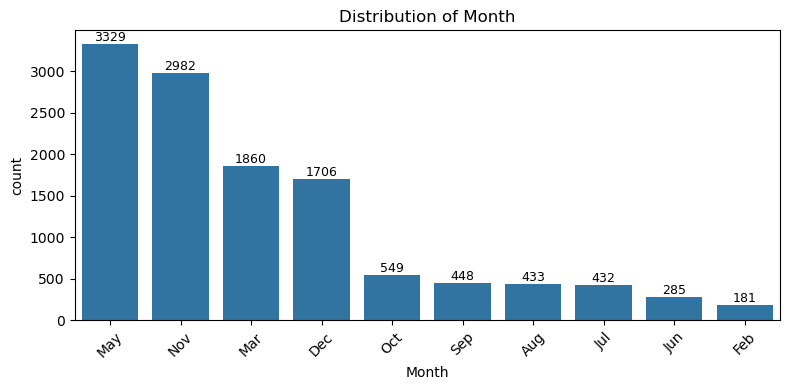

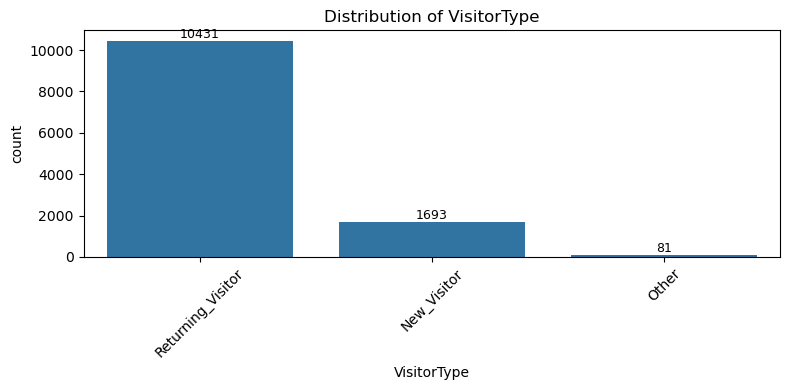

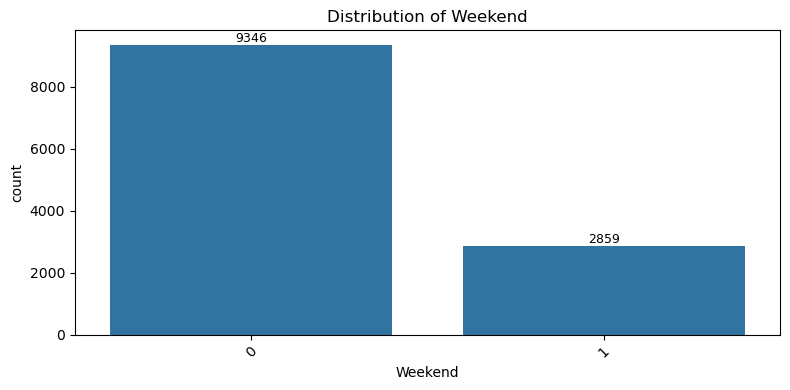

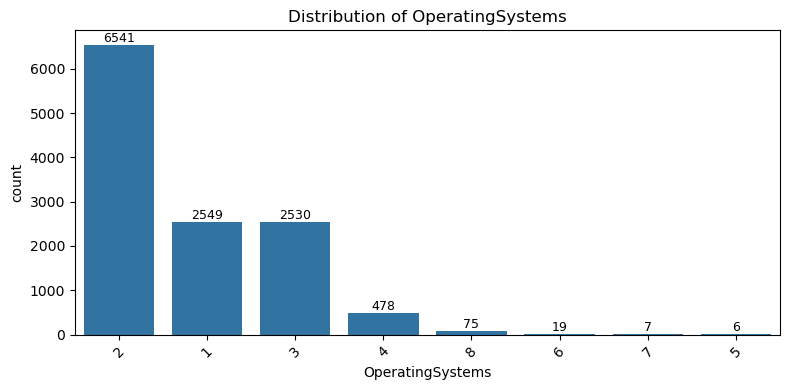

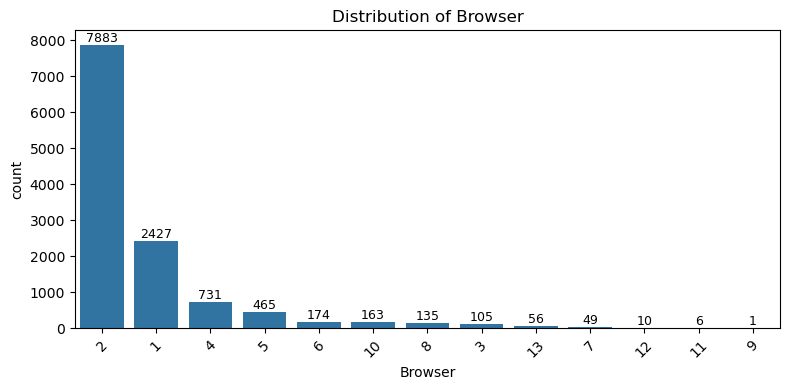

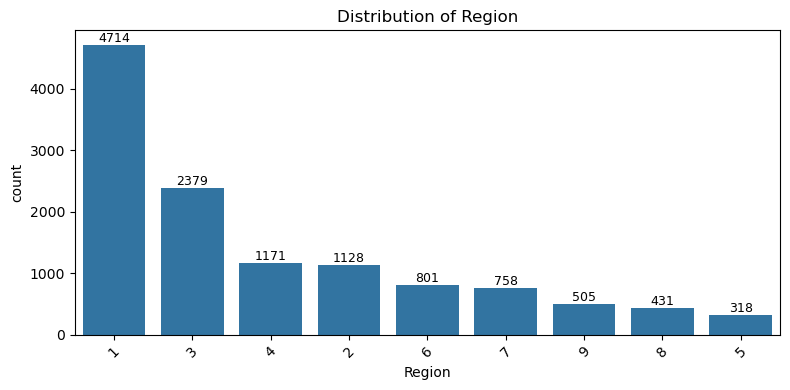

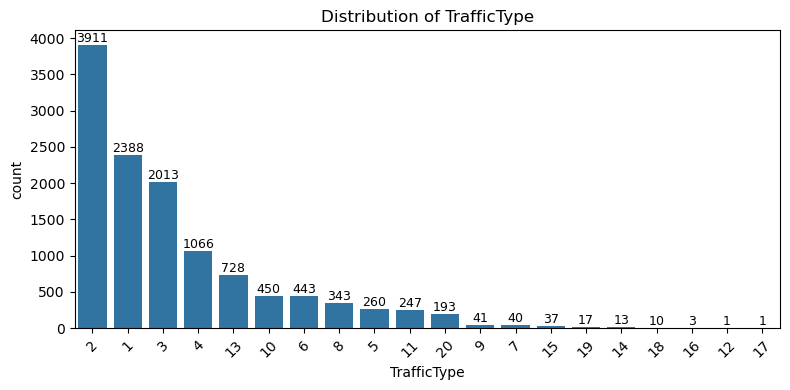

In [53]:
for col in cat_columns:
    plt.figure(figsize=(8,4))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', 
            va='bottom',
            fontsize=9)
    
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## <u><b> 2. EDA of Num_columns</u></b>

In [54]:
df[num_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.00000,2.33888,3.33044,0.00000,0.00000,1.00000,4.00000,27.00000
Administrative_Duration,12205.00000,81.64633,177.49185,0.00000,0.00000,9.00000,94.70000,3398.75000
Informational,12205.00000,0.50873,1.27562,0.00000,0.00000,0.00000,0.00000,24.00000
Informational_Duration,12205.00000,34.82545,141.42481,0.00000,0.00000,0.00000,0.00000,2549.37500
ProductRelated,12205.00000,32.04564,44.59365,0.00000,8.00000,18.00000,38.00000,705.00000
ProductRelated_Duration,12205.00000,1206.98246,1919.60140,0.00000,193.00000,608.94286,1477.15476,63973.52223
BounceRates,12205.00000,0.02037,0.04526,0.00000,0.00000,0.00290,0.01667,0.20000
ExitRates,12205.00000,0.04147,0.04616,0.00000,0.01423,0.02500,0.04853,0.20000
PageValues,12205.00000,5.94957,18.65367,0.00000,0.00000,0.00000,0.00000,361.76374
SpecialDay,12205.00000,0.06194,0.19967,0.00000,0.00000,0.00000,0.00000,1.00000


####  <span style="color:blue">Insights:</span>
- Users spent significantly more time on product-related pages compared to administrative and informational pages, making product pages the primary area of customer engagement, with an average browsing duration of 1206 seconds.
-  Most users browsed around 18 product pages per session. However, the average appears higher at 32 because a small group of users visited 100+ product pages, pulling the average up.
- Most sessions recorded very low BounceRates of 0.02 and ExitRates of 0.041, showing that users generally remained engaged and explored multiple pages instead of leaving quickly.
- A smaller group of highly engaged users generated exceptionally high PageValues reaching 361, product browsing durations up to 63973 seconds, and as many as 705 product interactions, indicating strong purchase intent and highly valuable customer behavior.

####  <span style="color:green">Recommendations:</span>
- Optimize product pages and improve product recommendations, as most users browse around 18 product pages and spend over 1,000 seconds on product-related pages per session — indicating strong product engagement that can be converted into purchases with better page experience.
- Maintain the current website experience because average BounceRate (0.02) and ExitRate (0.041) are already very low, indicating good engagement.
- Target highly engaged users with personalized offers and remarketing campaigns, as some sessions show extremely high PageValues (361) and ProductRelated_Duration (63973 sec).
- Improve informational page content because average informational page visits (0.50) and duration (34 sec) are very low.

### <b>Distribution (Histogram + Boxplot) for all Numerical Variables</b>

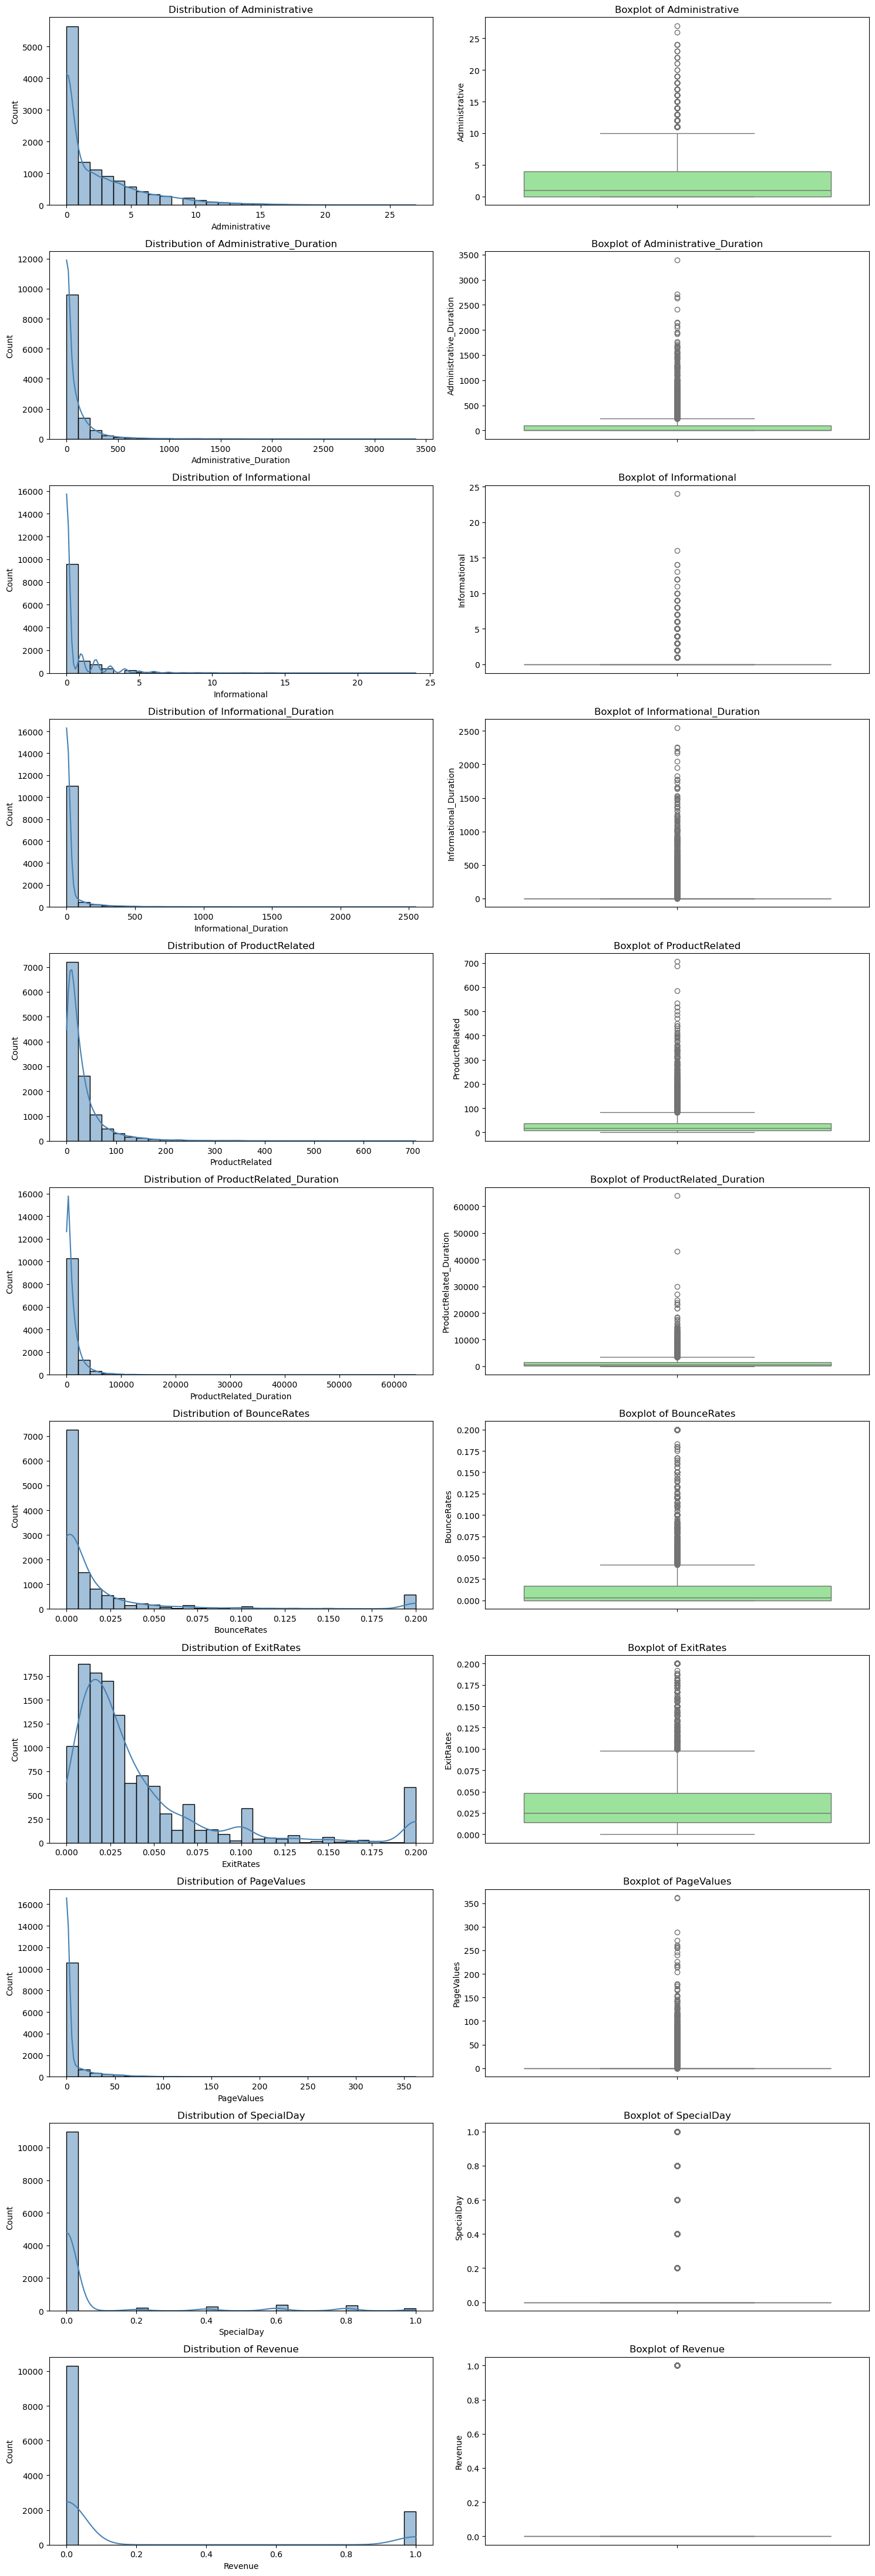

In [55]:
fig, axes = plt.subplots(len(num_columns), 2, figsize=(15, len(num_columns) * 4))

for i, col in enumerate(num_columns):
    
    #Histogram  → shows distribution shape and skewness
    sns.histplot(df[col], bins=30, kde=True, color="steelblue", ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribution of {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    #Boxplot  → shows spread, median and outliers
    sns.boxplot(data=df, y=col, color="lightgreen", ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot of {col}")
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()


In [56]:
df['SpecialDay'].value_counts()

SpecialDay
0.00000    10956
0.60000      350
0.80000      324
0.40000      243
0.20000      178
1.00000      154
Name: count, dtype: int64

# <u><b>BIVARIATE ANALYSIS</u></b> (Num-Num, Cat-Cat, Num-Cat)

## <u><b>NUM-NUM ANALYSIS</u></b>

In [57]:
df[num_columns].corr() # corelation  

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Revenue
Administrative,1.00000,0.60046,0.37526,0.25481,0.42830,0.37115,-0.21310,-0.31125,0.09702,-0.09695,0.13633
Administrative_Duration,0.60046,1.00000,0.30142,0.23721,0.28686,0.35358,-0.13691,-0.20197,0.06623,-0.07467,0.09177
Informational,0.37526,0.30142,1.00000,0.61865,0.37257,0.38605,-0.10910,-0.15943,0.04741,-0.04935,0.09363
Informational_Duration,0.25481,0.23721,0.61865,1.00000,0.27908,0.34660,-0.06988,-0.10285,0.03009,-0.03126,0.06936
ProductRelated,0.42830,0.28686,0.37257,0.27908,1.00000,0.86033,-0.19288,-0.28608,0.05420,-0.02584,0.15604
ProductRelated_Duration,0.37115,0.35358,0.38605,0.34660,0.86033,1.00000,-0.17383,-0.24527,0.05092,-0.03812,0.15008
BounceRates,-0.21310,-0.13691,-0.10910,-0.06988,-0.19288,-0.17383,1.00000,0.90214,-0.11580,0.08863,-0.14509
ExitRates,-0.31125,-0.20197,-0.15943,-0.10285,-0.28608,-0.24527,0.90214,1.00000,-0.17363,0.11718,-0.20432
PageValues,0.09702,0.06623,0.04741,0.03009,0.05420,0.05092,-0.11580,-0.17363,1.00000,-0.06448,0.49189
SpecialDay,-0.09695,-0.07467,-0.04935,-0.03126,-0.02584,-0.03812,0.08863,0.11718,-0.06448,1.00000,-0.08360


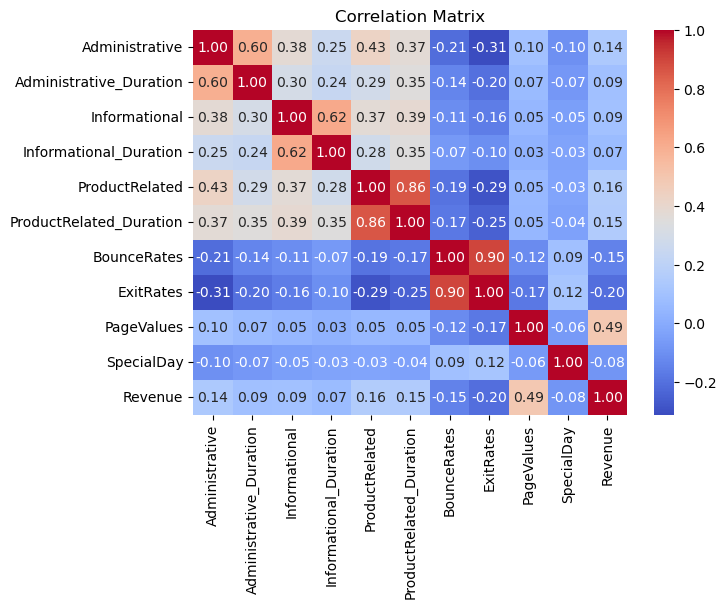

In [58]:
plt.figure(figsize=(7,5))
sns.heatmap(df[num_columns].corr(), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

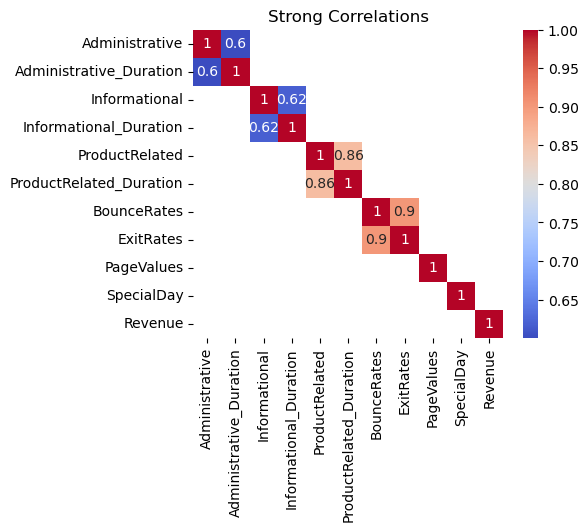

In [59]:
corr = df[num_columns].corr()

# strong correlations 
strong_corr = corr[(corr > 0.5) | (corr < -0.5)]

plt.figure(figsize=(5,4))
sns.heatmap(strong_corr, annot=True, cmap='coolwarm')
plt.title("Strong Correlations")
plt.show()


#### I selected below visualizations based not only on correlation strength but also on business relevance and impact on customer behavior and revenue.”


## <u><b>BounceRates vs ExitRates</u></b> 
#### [Correlation = 0.90 (Very Strong Positive Correlation)]

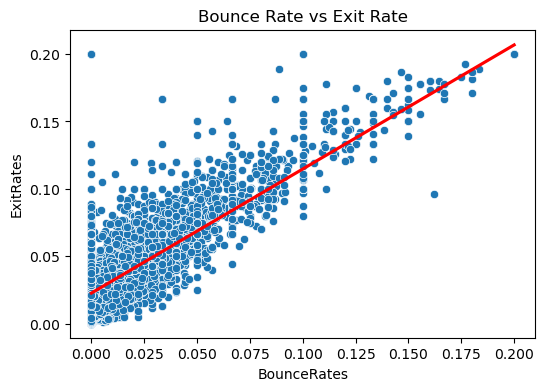

In [60]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='BounceRates',
                y='ExitRates',
                data=df)
sns.regplot(x='BounceRates',
            y='ExitRates',
            data=df,
            scatter=False, color='red')
plt.title('Bounce Rate vs Exit Rate')
plt.xlabel('BounceRates')
plt.ylabel('ExitRates')
plt.show()

####  <span style="color:blue">Insight:</span>

Users with high bounce rates also showed high exit behavior, indicating that users leaving quickly are highly likely to abandon the website completely.

####  <span style="color:green">Recommendation:</span>

Optimize landing pages, website navigation, and page loading speed to reduce customer drop-offs and improve engagement.

## <u><b>ProductRelated vs ProductRelated_Duration</u></b>
#### [Correlation = 0.86 (Strong Positive Correlation)]


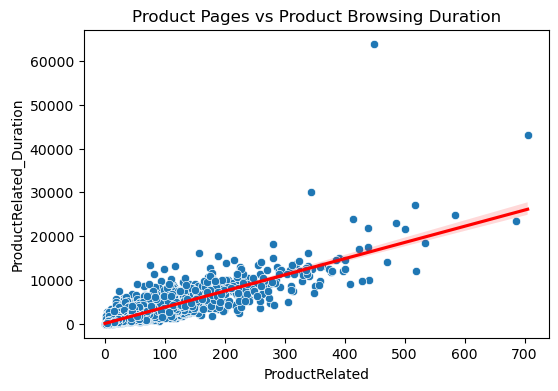

In [61]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='ProductRelated',
                y='ProductRelated_Duration',
                data=df)
sns.regplot(x='ProductRelated',
            y='ProductRelated_Duration',
            data=df,
            scatter=False, color='red')
plt.title('Product Pages vs Product Browsing Duration')
plt.xlabel('ProductRelated')
plt.ylabel('ProductRelated_Duration')
plt.show()

####  <span style="color:blue">Insight:</span>

Users who viewed more product pages also spent significantly more time browsing products, indicating strong product engagement and shopping interest.

####  <span style="color:green">Recommendation:</span>

Improve product recommendations, product discovery, and product page experience to further increase customer engagement and conversions.

## <u><b>Informational vs Informational_Duration</u></b>
#### [Correlation = 0.62 (Strong Positive Correlation)]

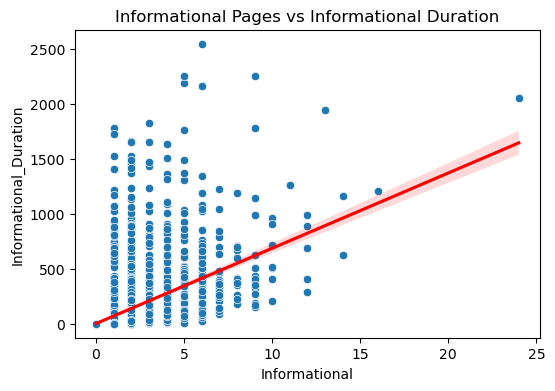

In [62]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Informational',
                y='Informational_Duration',
                data=df)
sns.regplot(x='Informational',
            y='Informational_Duration',
            data=df,
            scatter=False, color='red')
plt.title('Informational Pages vs Informational Duration')
plt.show()

####  <span style="color:blue">Insight:</span>

Users who visited more informational pages also spent more time reading informational content, indicating consistent informational browsing behavior.

####  <span style="color:green">Recommendation:</span>

Improve informational content quality and visibility to increase customer awareness and engagement.

## <u><b>Administrative vs Administrative_Duration</u></b> 
#### [Correlation = 0.60 (Strong Positive Correlation)]

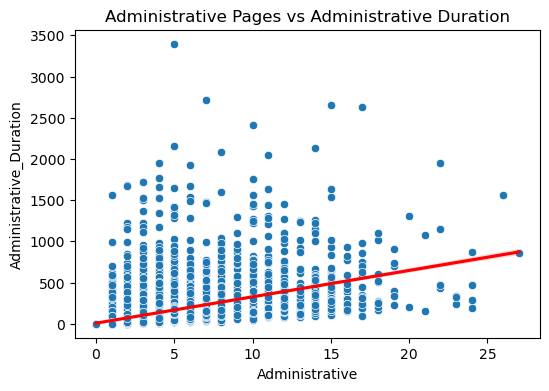

In [63]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Administrative',
                y='Administrative_Duration',
                data=df)
sns.regplot(x='Administrative',
            y='Administrative_Duration',
            data=df,
            scatter=False, color='red')
plt.title('Administrative Pages vs Administrative Duration')
plt.show()

####  <span style="color:blue">Insight:</span>

Users who visited more administrative pages also spent more time interacting with them, showing consistent navigation behavior.

####  <span style="color:green">Recommendation:</span>

Simplify administrative processes such as account management and checkout flow to improve overall user experience.

## <u><b>PageValues vs Revenue</u></b>

<Axes: xlabel='Revenue', ylabel='PageValues'>

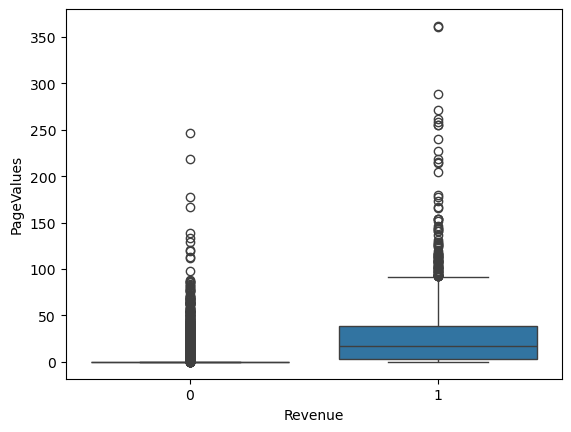

In [64]:
sns.boxplot(x='Revenue', y='PageValues', data=df)

####  <span style="color:blue">Insight:</span>
The boxplot shows that sessions generating revenue generally have higher PageValues compared to non-purchasing sessions. This suggests that pages with higher value contribute significantly to conversions.

####  <span style="color:green">Recommendation:</span>

Businesses should optimize and promote these high-performing pages to improve overall revenue.

## <u><b>ProductRelated vs Revenue</u></b>

<Axes: xlabel='Revenue', ylabel='ProductRelated'>

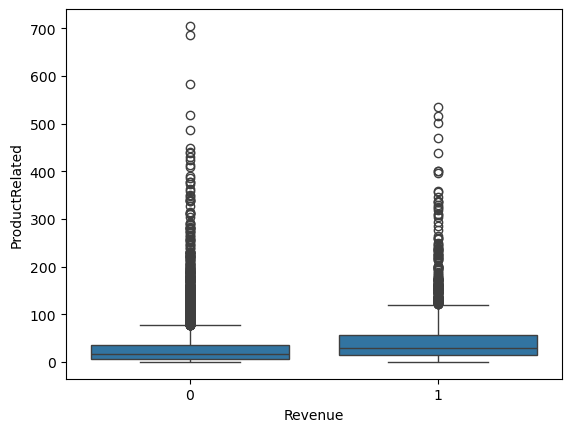

In [112]:
sns.boxplot(x='Revenue', y='ProductRelated', data=df)

####  <span style="color:blue">Insight:</span>
The boxplot indicates that users who generated revenue generally visited more product-related pages compared to non-purchasing users. This suggests that higher product engagement increases the likelihood of conversion.

####  <span style="color:green">Recommendation:</span>
Businesses should improve product discovery and optimize product pages to encourage deeper browsing and higher conversions.

## <u><b>ExitRates vs Revenue</u></b>

<Axes: xlabel='Revenue', ylabel='ExitRates'>

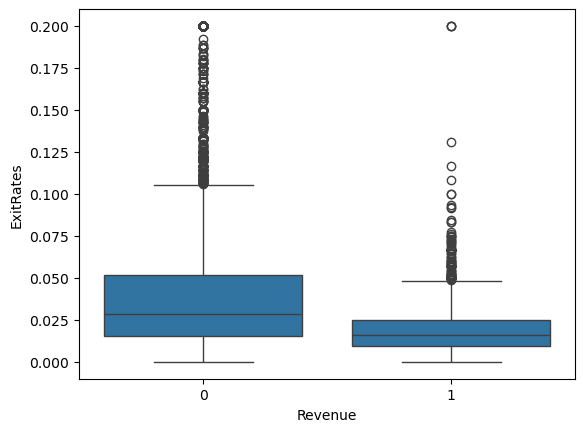

In [114]:
sns.boxplot(x='Revenue', y='ExitRates', data=df)

####  <span style="color:blue">Insight:</span>
The boxplot indicates that sessions generating revenue generally have lower exit rates, while non-converting sessions show higher exits. This suggests that users who exit frequently are significantly less likely to complete a purchase.
####  <span style="color:green">Recommendation:</span>

Identify and optimize high-exit pages to improve customer retention and conversions.

## <u><b>BounceRates vs Revenue</u></b>

<Axes: xlabel='Revenue', ylabel='BounceRates'>

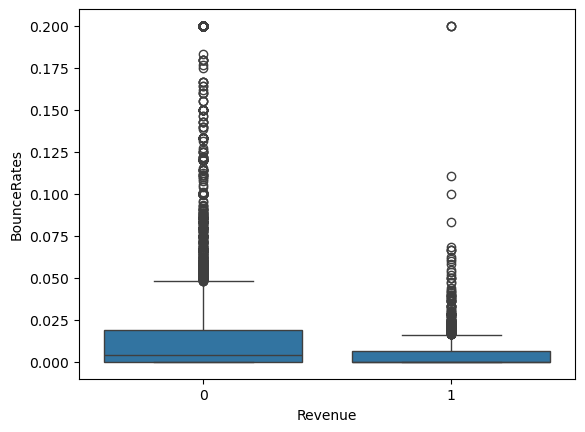

In [115]:
sns.boxplot(x='Revenue', y='BounceRates', data=df)

####  <span style="color:blue">Insight:</span>
The boxplot shows that purchasing users generally have lower bounce rates than non-purchasing users. This suggests that users who leave quickly after 
landing rarely return to complete a purchase.
####  <span style="color:green">Recommendation:</span>

Improve website engagement through better content visibility and smoother browsing experience.

# <u><b> CAT-CAT ANALYSIS</u></b>

### <u><b>Region vs VisitorType</u></b>

VisitorType,New_Visitor,Other,Returning_Visitor
Region,,,
1,656,8,4050
2,149,5,974
3,312,8,2059
4,139,5,1027
5,50,0,268
6,121,1,679
7,100,2,656
8,74,1,356
9,92,51,362


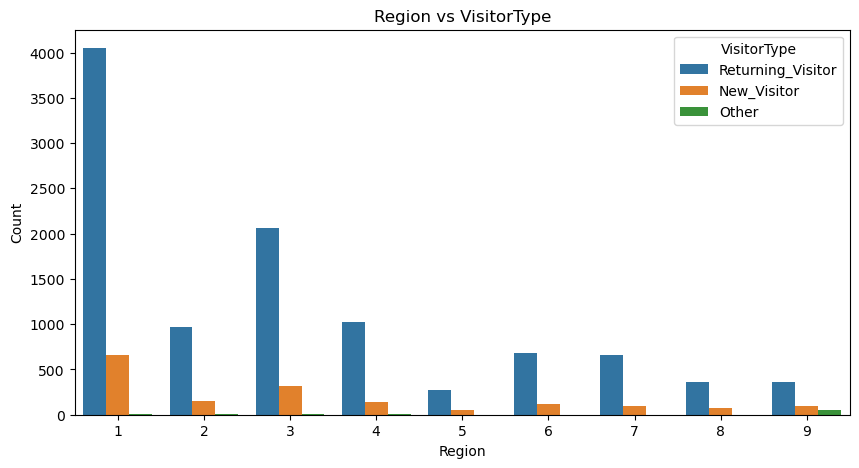

In [69]:
display(pd.crosstab(df['Region'], df['VisitorType']))

plt.figure(figsize=(10,5))
sns.countplot(
    x='Region',
    hue='VisitorType',
    data=df
)
plt.title('Region vs VisitorType')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

#### <span style="color:blue">Insight:</span>

Region 1 generated the highest number of returning visitors, indicating stronger customer loyalty and engagement in that region compared to others.

####  <span style="color:green">Recommendation:</span>

Increase region-specific marketing and personalized campaigns in high-performing regions while exploring strategies to improve engagement in lower-performing regions.

## <u><b>Weekend vs VisitorType</u></b>

VisitorType,New_Visitor,Other,Returning_Visitor
Weekend,,,
0,1214,74,8058
1,479,7,2373


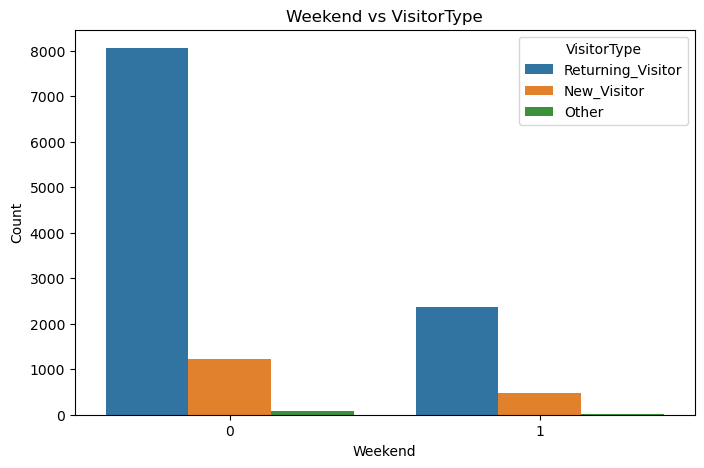

In [70]:
display(pd.crosstab(df['Weekend'], df['VisitorType']))

plt.figure(figsize=(8,5))
sns.countplot(
    x='Weekend',
    hue='VisitorType',
    data=df
)
plt.title('Weekend vs VisitorType')
plt.xlabel('Weekend')
plt.ylabel('Count')
plt.show()

#### <span style="color:blue">Insight:</span>

Both weekdays and weekends were dominated by returning visitors, although overall traffic was significantly higher during weekdays.

####  <span style="color:green">Recommendation:</span>

Prioritize major campaigns during weekdays while using weekends for targeted engagement offers to maintain customer activity throughout the week.

## <u><b>Month vs VisitorType</u></b>

VisitorType,New_Visitor,Other,Returning_Visitor
Month,,,
Aug,72,0,361
Dec,334,58,1314
Feb,1,0,180
Jul,54,0,378
Jun,30,1,254
Mar,232,0,1628
May,319,0,3010
Nov,419,22,2541
Oct,124,0,425


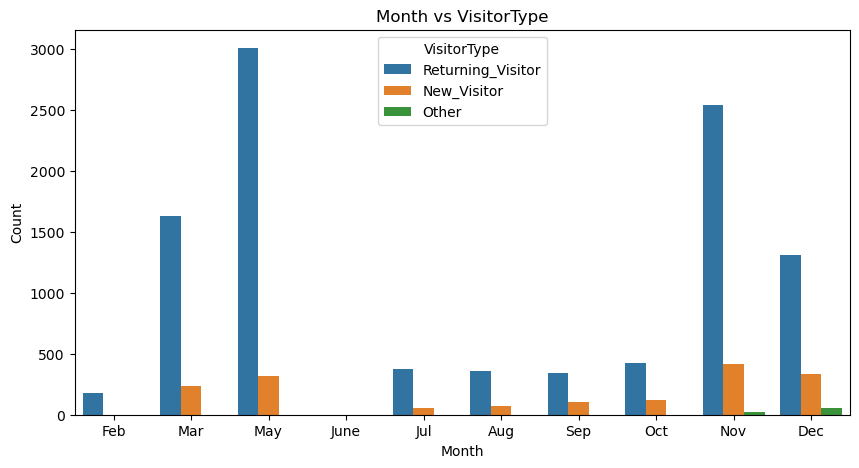

In [71]:
display(pd.crosstab(df['Month'], df['VisitorType']))

month_order  = ["Feb","Mar","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(10,5))
sns.countplot(
    x='Month',
    hue='VisitorType',
    data=df,
    order=month_order
)
plt.title('Month vs VisitorType')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

#### <span style="color:blue">Insight:</span>

Returning visitors were consistently higher across all months, with May and November generating the highest repeat visitor traffic, indicating strong customer engagement during peak shopping periods.
####  <span style="color:green">Recommendation:</span>

Launch retention campaigns, loyalty offers, and remarketing strategies during high-traffic months like May and November to maximize repeat purchases and conversions.

## <u><b>TrafficType vs VisitorType</u></b>

VisitorType,New_Visitor,Other,Returning_Visitor
TrafficType,,,
1,37,7,2344
2,935,11,2965
3,140,7,1866
4,99,0,967
5,149,1,110
6,42,1,400
7,5,0,35
8,175,1,167
9,9,0,32


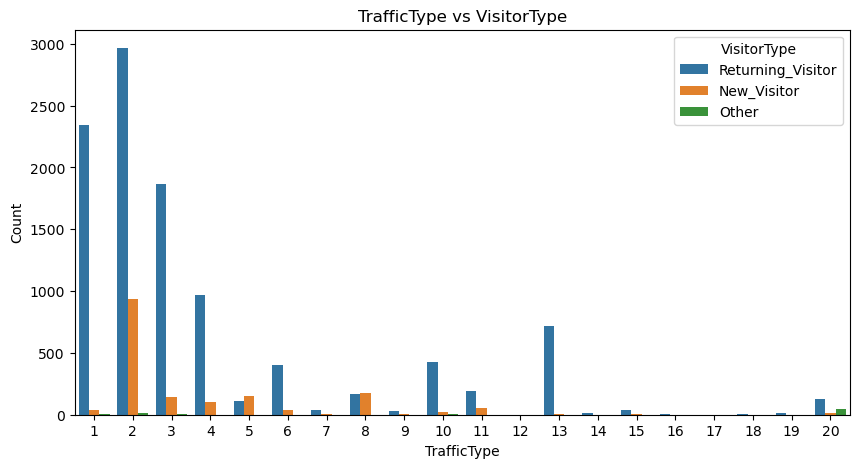

In [72]:
display(pd.crosstab(df['TrafficType'], df['VisitorType']))

plt.figure(figsize=(10,5))
sns.countplot(
    x='TrafficType',
    hue='VisitorType',
    data=df
)
plt.title('TrafficType vs VisitorType')
plt.xlabel('TrafficType')
plt.ylabel('Count')
plt.show()

#### <span style="color:blue">Insight:</span>

Returning visitors dominated almost all traffic sources, especially TrafficType 1, 2, and 3, indicating that these channels attract more repeat and engaged customers.

####  <span style="color:green">Recommendation:</span>

Focus marketing investments on high-performing traffic sources that consistently bring returning visitors, as they show stronger customer retention potential.

## <b>Categorical Variables vs Revenue Analysis</b>

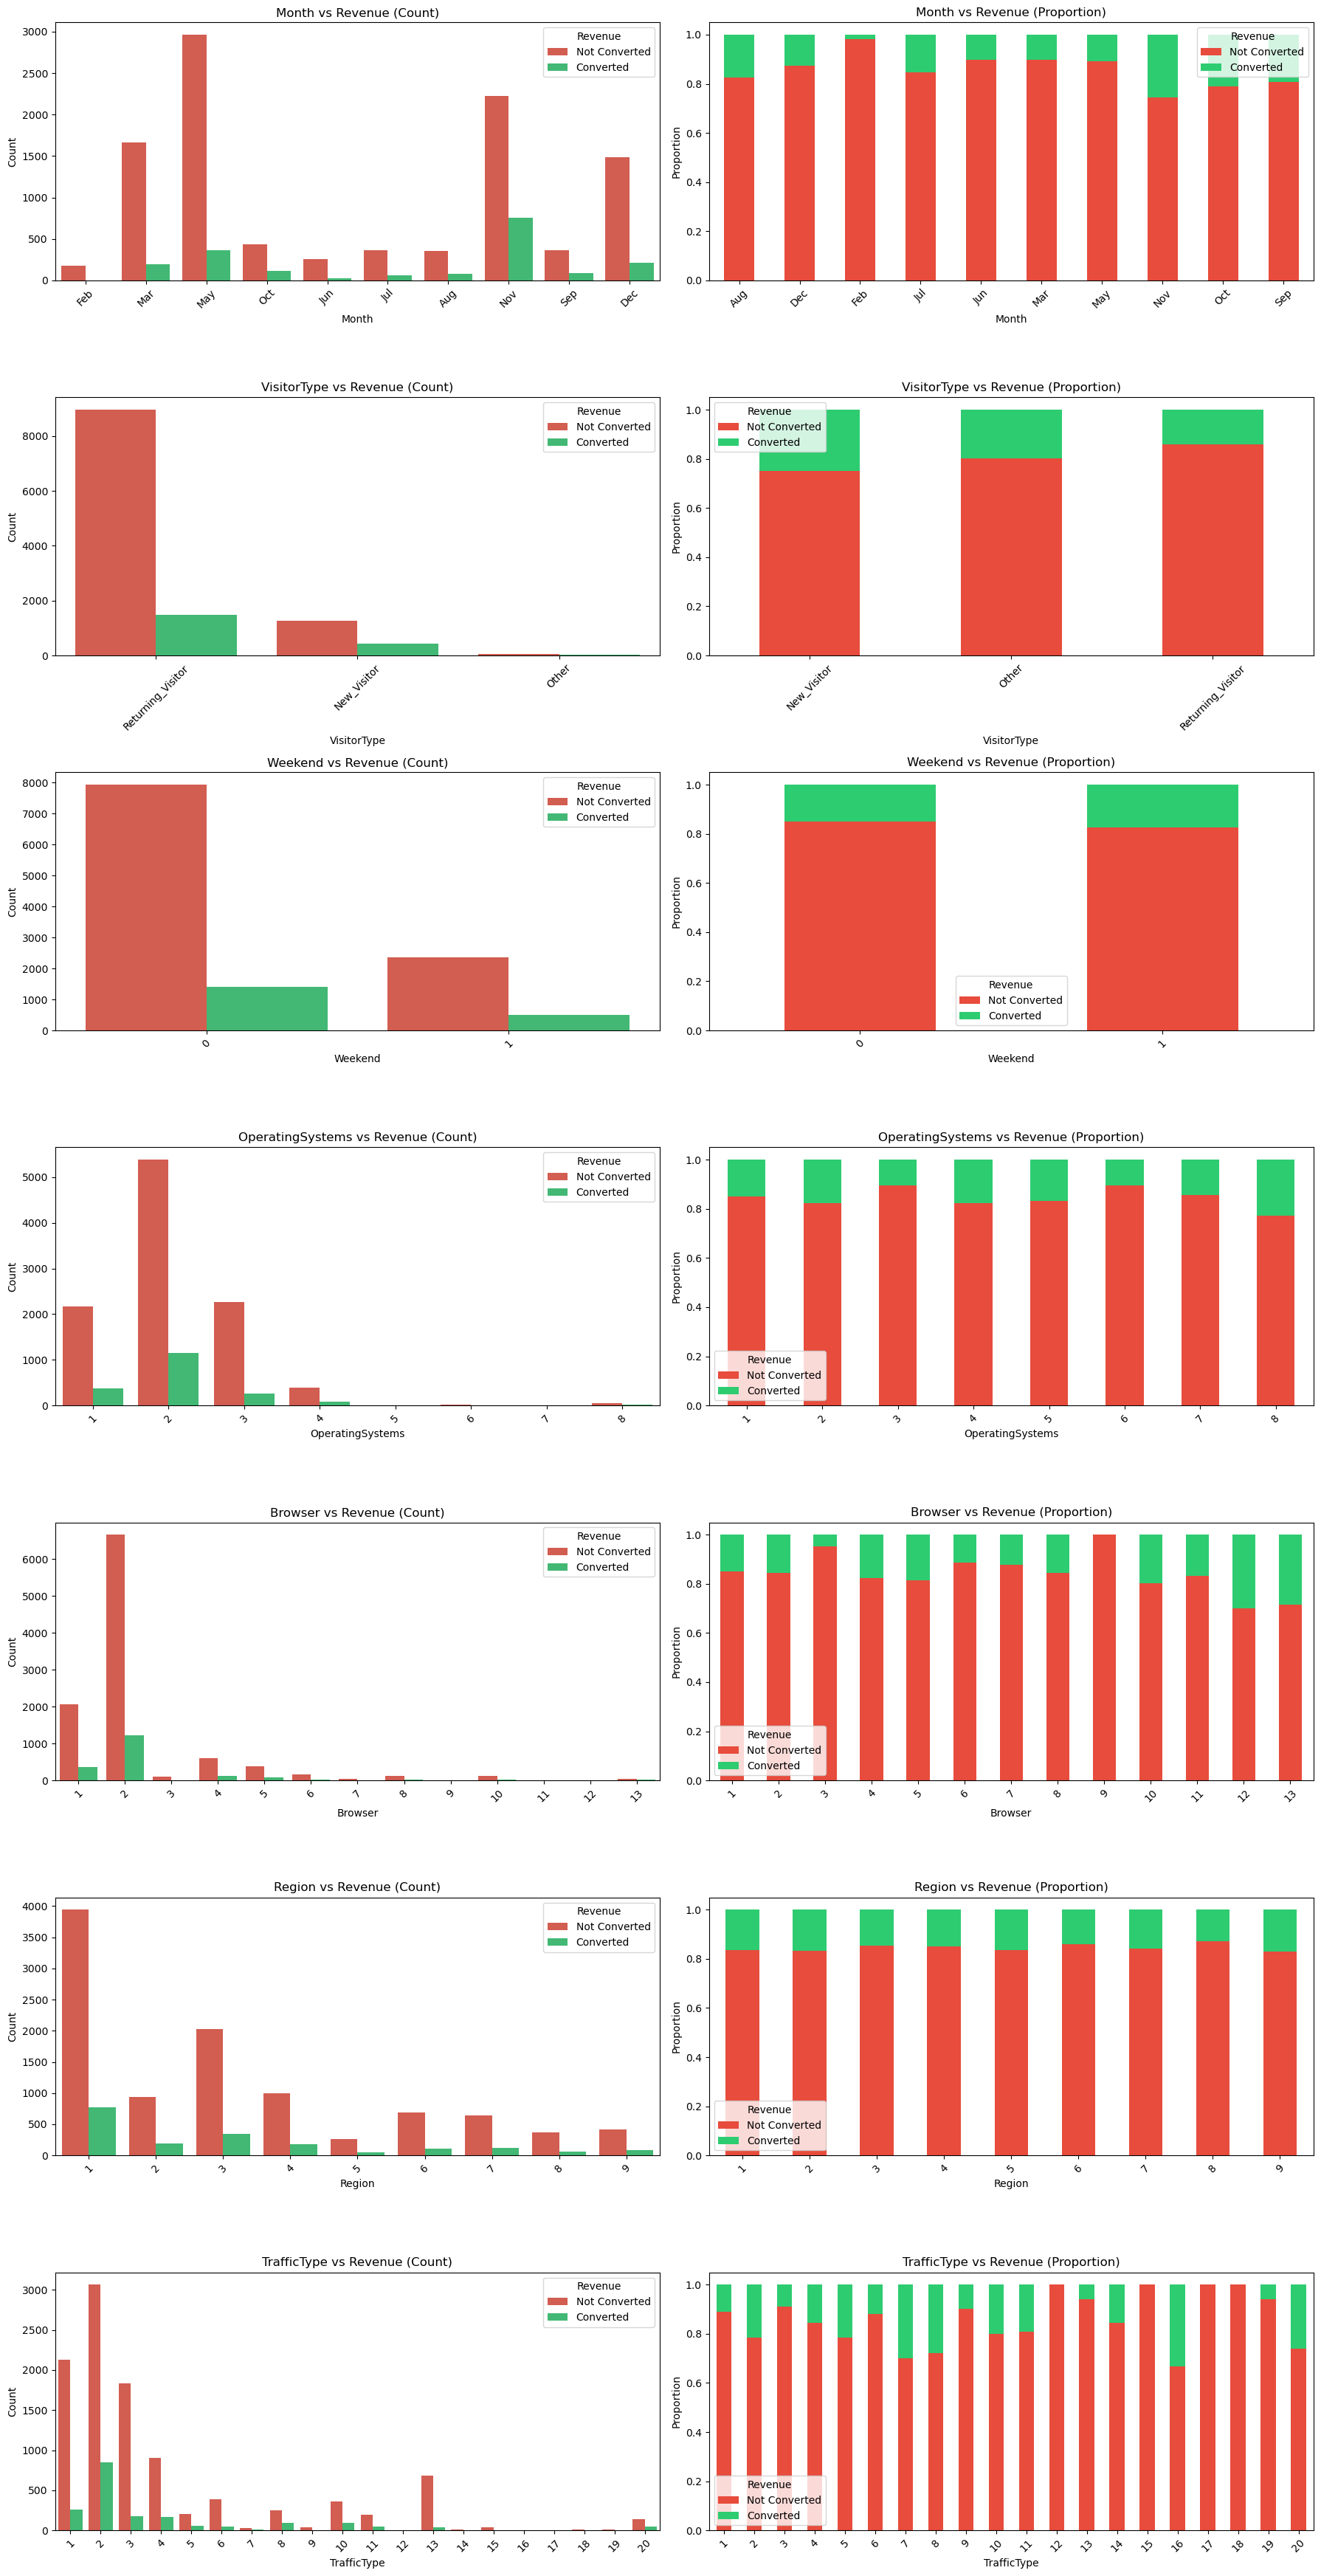

In [73]:
fig, axes = plt.subplots(len(cat_columns), 2, figsize=(18, len(cat_columns) * 5))

for i, col in enumerate(cat_columns):
    
    # Countplot
    sns.countplot(data=df, x=col, hue="Revenue", 
                  palette={0:"#E74C3C", 1:"#2ECC71"}, 
                  ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} vs Revenue (Count)")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")
    axes[i, 0].legend(title="Revenue", labels=["Not Converted", "Converted"])
    axes[i, 0].tick_params(axis="x", rotation=45)

    # Stacked Bar
    pd.crosstab(df[col], df["Revenue"], normalize="index").plot(
        kind="bar", 
        stacked=True, 
        color=["#E74C3C","#2ECC71"],
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{col} vs Revenue (Proportion)")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Proportion")
    axes[i, 1].legend(title="Revenue", labels=["Not Converted", "Converted"])
    axes[i, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## <b>Conversion Rate Analysis</b>

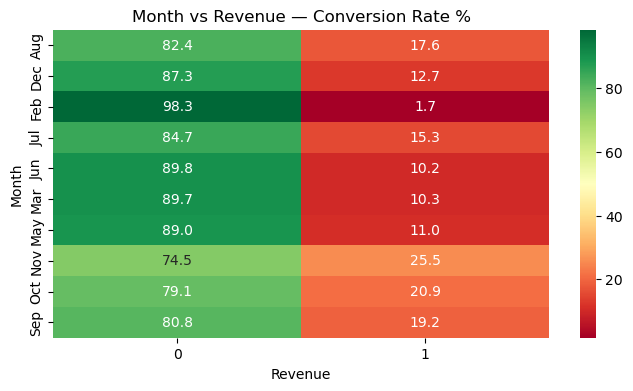

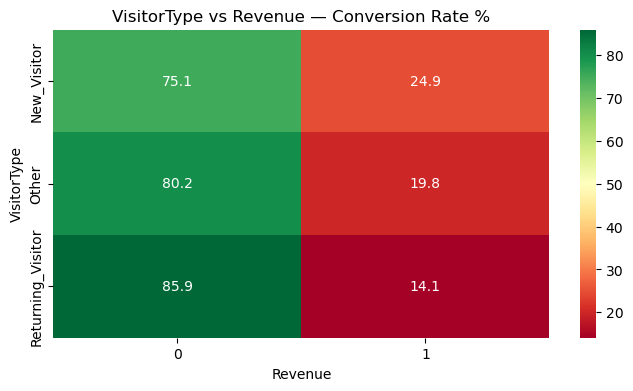

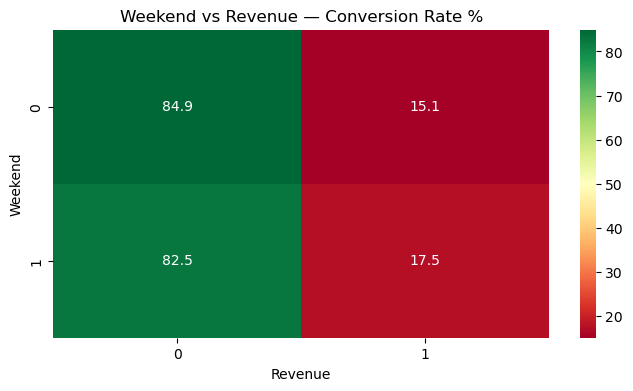

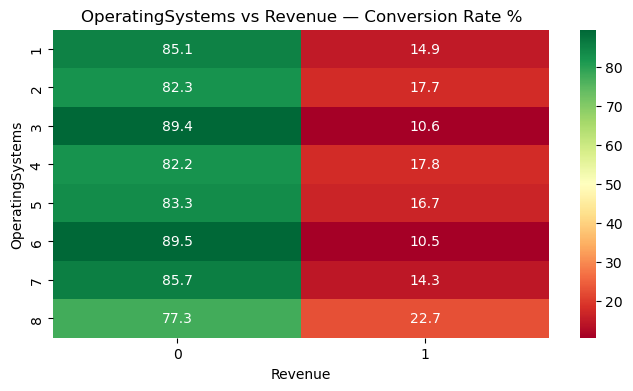

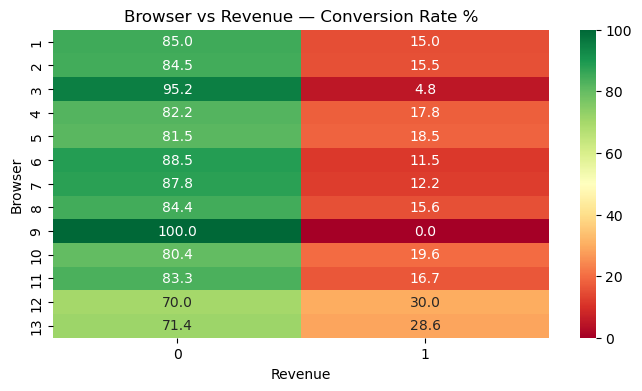

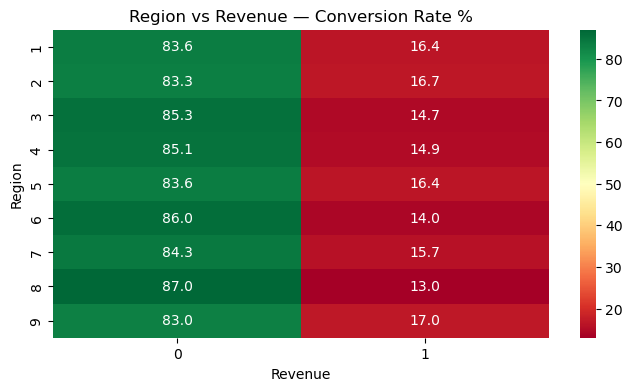

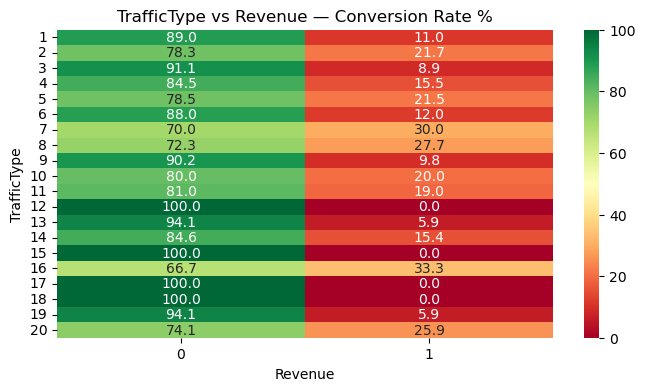

In [74]:
for col in cat_columns:
    plt.figure(figsize=(8, 4))
    ct = pd.crosstab(df[col], df["Revenue"], normalize="index")*100 
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="RdYlGn")
    plt.title(f"{col} vs Revenue — Conversion Rate %")
    plt.show()

#### <span style="color:blue">Insights:</span>
- November showed the highest customer purchasing activity with the highest conversion rate of 25.5%, while February recorded the lowest conversion rate of only 1.7%, indicating strong seasonal variation in shopping behavior.
- Returning visitors generated the highest number of purchases overall, while New Visitors achieved the highest conversion rate of 24.9%, showing strong purchase intent among first-time buyers.
- Weekend sessions had a higher conversion rate of 17.5% compared to weekdays, suggesting that users were more likely to make purchases during weekends.
- Operating System 2 and Browser 2 generated the highest traffic and purchases, indicating that most customers used these platforms for browsing and shopping activity.
- Certain browser and operating system categories such as Browser 13, Browser 12, and Operating System 8 showed exceptionally high conversion rates, indicating highly engaged customer segments.
- Region 1 contributed the highest overall purchases, while Region 9 achieved the highest conversion rate, showing stronger purchasing efficiency in specific regions.
- TrafficType 16 achieved the highest conversion rate of 33.3%, whereas TrafficType 15,17,18 performed poorly in conversions.

####  <span style="color:green">Recommendations:</span>
- Increase marketing campaigns, promotional offers, and inventory planning during high-performing months such as November and October to maximize seasonal sales opportunities.
- Focus on customer acquisition strategies to attract more new visitors while continuing retention campaigns for returning customers.
- Launch weekend-focused promotions and personalized offers to capitalize on higher weekend conversion behavior.
- Optimize website performance for the most-used browsers and operating systems.
- Analyze high-converting browser, operating system, and regional segments to identify customer behavior patterns that can be replicated across weaker-performing segments.
- Invest more in high-converting traffic sources and improve low-performing traffic channels

# <u><b> NUM-CAT ANALYSIS</u></b>

## <u><b>PageValues vs VisitorType<u><b>

In [75]:
df.groupby('VisitorType').agg({'PageValues': ["mean", "min", "max", "std", "count"]})

PageValues                                  
                        mean     min       max      std  count
VisitorType                                                   
New_Visitor         10.77855 0.00000 361.76374 29.19723   1693
Other               19.09017 0.00000 360.95338 54.32814     81
Returning_Visitor    5.06377 0.00000 255.56916 15.50161  10431

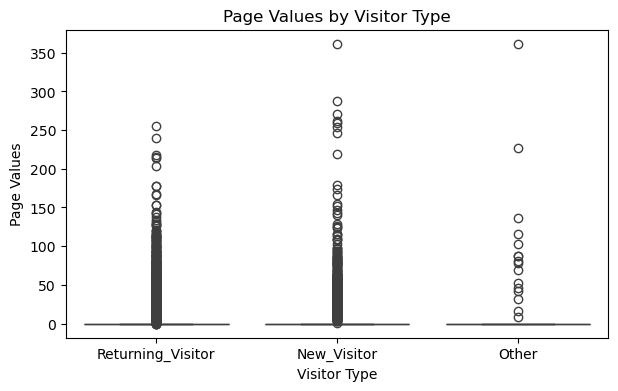

In [119]:
plt.figure(figsize=(7,4))

sns.boxplot(x='VisitorType',
            y='PageValues',
            data=df)

plt.title('Page Values by Visitor Type')
plt.xlabel('Visitor Type')
plt.ylabel('Page Values')

plt.show()

#### <span style="color:blue">Insight:</span>
- Other visitors have the highest average Page Value (19.09), followed by New_Visitor (10.78).
- Returning_Visitor has the lowest Page Value (~5.06).
- New visitors appear to show stronger purchase intent than returning visitors.

####  <span style="color:green">Recommendation:</span>
- Retarget high-intent new visitors with personalized offers and product recommendations.
- Improve upselling strategies for returning visitors to increase their purchase value.


## <u><b>PageValues vs Month<u><b>

In [77]:
df.groupby('Month').agg({'PageValues': ["mean", "min", "max", "std", "count"]})

PageValues                                 
            mean     min       max      std count
Month                                            
Aug      5.93807 0.00000 153.57770 15.94990   433
Dec      6.91736 0.00000 360.95338 23.06820  1706
Feb      0.90512 0.00000  54.17976  5.57594   181
Jul      4.10441 0.00000  79.44353 11.02579   432
Jun      3.42714 0.00000 166.37355 12.93646   285
Mar      4.05974 0.00000 261.49129 14.46470  1860
May      5.48868 0.00000 254.60716 16.69064  3329
Nov      7.16763 0.00000 361.76374 21.00122  2982
Oct      8.64558 0.00000 246.75859 21.50856   549
Sep      7.55683 0.00000 258.54987 21.82993   448

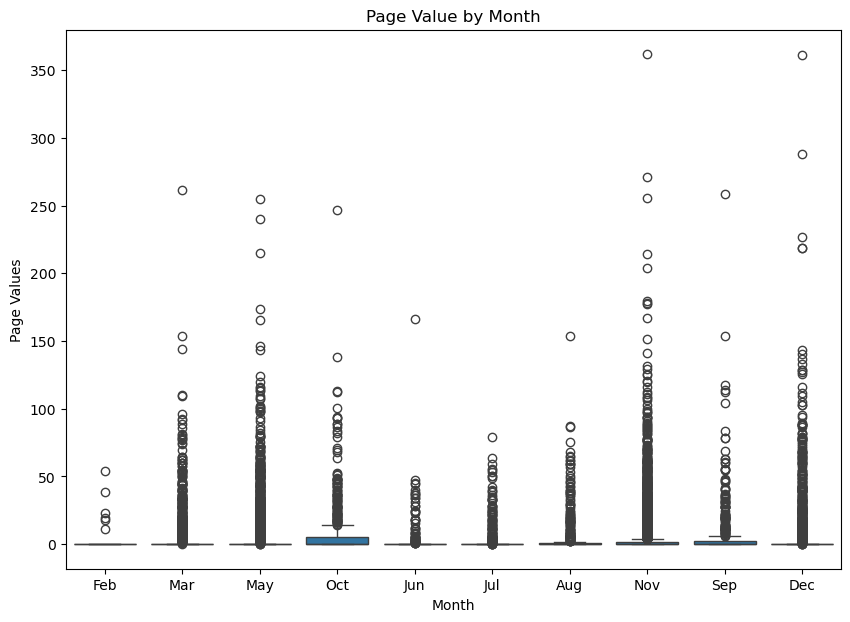

In [133]:
plt.figure(figsize=(10,7))

sns.boxplot(x='Month',
            y='PageValues',
            data=df)

plt.title('Page Value by Month')
plt.xlabel('Month')
plt.ylabel('Page Values')

plt.show()

#### <span style="color:blue">Insight:</span>
- Highest Page Values observed in October (8.65) ,September (7.56) , November (7.17) and December (6.92).
- February shows the lowest Page Value (0.91).
- Users display stronger buying intent during festive and seasonal months.

####  <span style="color:green">Recommendation:</span>
- Increase promotional campaigns and inventory during Sep–Dec.
- Improve engagement campaigns during low-performing months like February.

## <u><b>BounceRates vs VisitorType<u><b>

In [79]:
df.groupby('VisitorType').agg({'BounceRates': ["mean", "min", "max", "std", "count"]})

BounceRates                               
                         mean     min     max     std  count
VisitorType                                                 
New_Visitor           0.00515 0.00000 0.20000 0.02589   1693
Other                 0.03058 0.00000 0.20000 0.07136     81
Returning_Visitor     0.02276 0.00000 0.20000 0.04695  10431

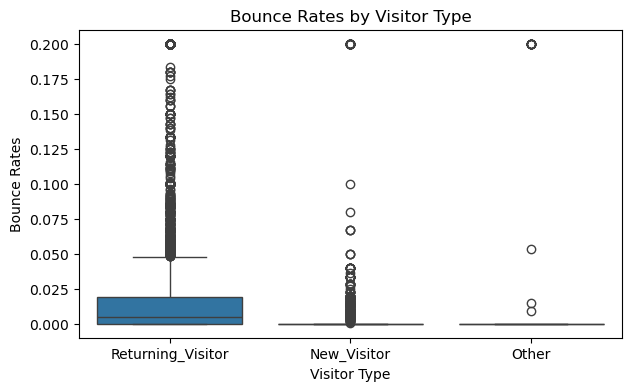

In [116]:
plt.figure(figsize=(7,4))

sns.boxplot(x='VisitorType',
            y='BounceRates',
            data=df)

plt.title('Bounce Rates by Visitor Type')
plt.xlabel('Visitor Type')
plt.ylabel('Bounce Rates')

plt.show()

#### <span style="color:blue">Insight:</span>
New Visitors showed the lowest average BounceRates, indicating better engagement and lower immediate drop-off compared to other visitor groups.

####  <span style="color:green">Recommendation:</span>
Improve website experience and retention strategies for Returning and Other visitor groups to reduce bounce behavior.


## <u><b>BounceRates vs TrafficType<u><b>

In [81]:
df.groupby('TrafficType').agg({'BounceRates': ["mean", "min", "max", "std", "count"]})

BounceRates                              
                   mean     min     max     std count
TrafficType                                          
1               0.02792 0.00000 0.20000 0.05259  2388
2               0.00836 0.00000 0.20000 0.02636  3911
3               0.03008 0.00000 0.20000 0.05430  2013
4               0.01574 0.00000 0.20000 0.03736  1066
5               0.00945 0.00000 0.20000 0.03269   260
6               0.02170 0.00000 0.20000 0.04635   443
7               0.00782 0.00000 0.05000 0.01244    40
8               0.01150 0.00000 0.20000 0.03640   343
9               0.02211 0.00000 0.20000 0.05968    41
10              0.01663 0.00000 0.20000 0.04212   450
11              0.02221 0.00000 0.20000 0.04848   247
12              0.00000 0.00000 0.00000     NaN     1
13              0.04663 0.00000 0.20000 0.06009   728
14              0.00243 0.00000 0.01538 0.00511    13
15              0.06641 0.00000 0.20000 0.08108    37
16              0.00000 0.00000 0.00000 0.00000     3
17              0.05000 0.05000 0.05000     NaN     1
18              0.03313 0.00000 0.20000 0.06231    10
19              0.02575 0.00000 0.20000 0.04947    17
20              0.02307 0.00000 0.20000 0.05310   193

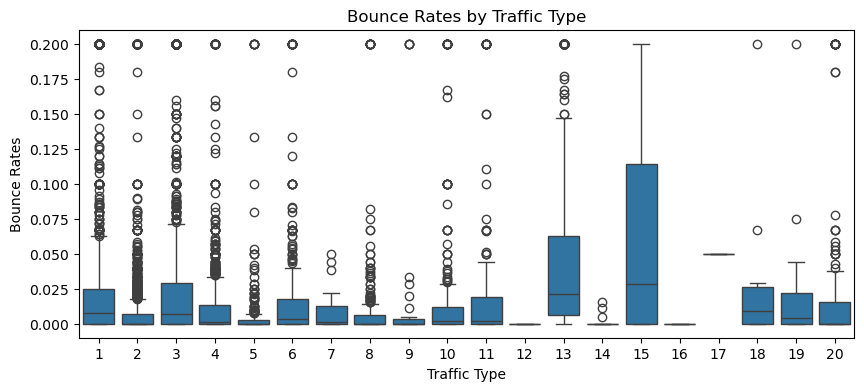

In [121]:
plt.figure(figsize=(10,4))

sns.boxplot(x='TrafficType',
            y='BounceRates',
            data=df)

plt.title('Bounce Rates by Traffic Type')
plt.xlabel('Traffic Type')
plt.ylabel('Bounce Rates')

plt.show()

#### <span style="color:blue">Insight:</span>
- Traffic Types 15, 13, and 3 have the highest bounce rates indicating poor-quality traffic and weak engagement.
- Traffic Types 2, 5, and 7 show the lowest bounce rates, indicating better-quality traffic.

####  <span style="color:green">Recommendation:</span>
- Optimize or reevaluate low-performing traffic sources 
- Invest more in high-quality traffic channels with lower bounce rates.


## <u><b>ExitRates vs VisitorType<u><b>

In [83]:
df.groupby('VisitorType').agg({'ExitRates': ["mean", "min", "max", "std", "count"]})

ExitRates                               
                       mean     min     max     std  count
VisitorType                                               
New_Visitor         0.02057 0.00000 0.20000 0.02840   1693
Other               0.05660 0.00067 0.20000 0.06580     81
Returning_Visitor   0.04474 0.00000 0.20000 0.04739  10431

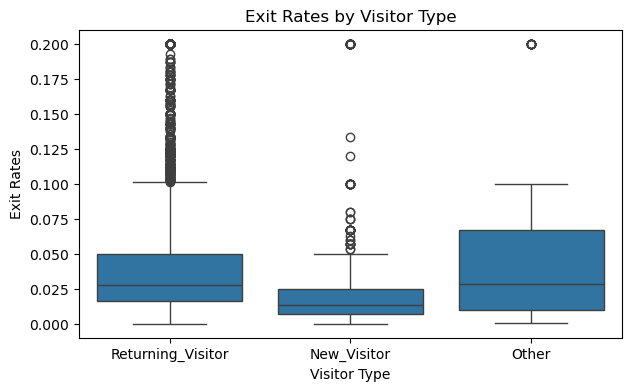

In [122]:
plt.figure(figsize=(7,4))

sns.boxplot(x='VisitorType',
            y='ExitRates',
            data=df)

plt.title('Exit Rates by Visitor Type')
plt.xlabel('Visitor Type')
plt.ylabel('Exit Rates')

plt.show()

#### <span style="color:blue">Insight:</span>
Other and Returning Visitors had higher ExitRates compared to New Visitors, suggesting they were more likely to leave the website before conversion.

####  <span style="color:green">Recommendation:</span>
Improve navigation, personalized recommendations, and retention strategies to reduce exit behavior among existing users.


## <u><b>ProductRelated_Duration vs VisitorType<u><b>

In [85]:
df.groupby('VisitorType').agg({'ProductRelated_Duration': ["mean", "min", "max", "std", "count"]})

ProductRelated_Duration                                 \
                                     mean     min         max        std   
VisitorType                                                                
New_Visitor                     636.76925 0.00000 12983.78771  766.40707   
Other                           598.57300 0.00000  9630.20952 1288.76458   
Returning_Visitor              1304.25521 0.00000 63973.52223 2034.32387   

                          
                   count  
VisitorType               
New_Visitor         1693  
Other                 81  
Returning_Visitor  10431

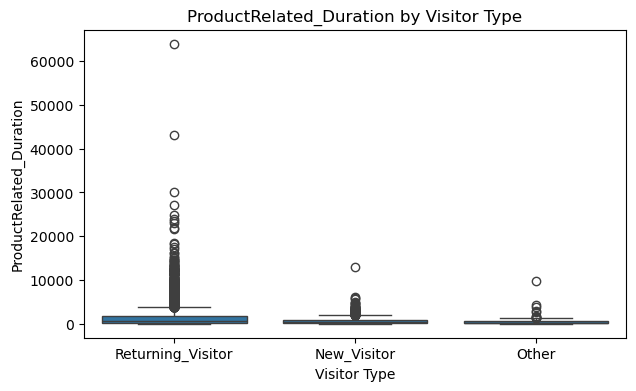

In [123]:
plt.figure(figsize=(7,4))

sns.boxplot(x='VisitorType',
            y='ProductRelated_Duration',
            data=df)

plt.title('ProductRelated_Duration by Visitor Type')
plt.xlabel('Visitor Type')
plt.ylabel('ProductRelated_Duration')

plt.show()

#### <span style="color:blue">Insight:</span>
Returning Visitors spent significantly more time on product pages, indicating stronger browsing engagement and shopping intent.

####  <span style="color:green">Recommendation:</span>
Target Returning Visitors with personalized product recommendations and remarketing campaigns to improve conversions.


## <u><b>ProductRelated_Duration vs Month<u><b>

In [87]:
df.groupby('Month').agg({'ProductRelated_Duration': ["mean", "min", "max", "std", "count"]})

ProductRelated_Duration                                     
                         mean     min         max        std count
Month                                                             
Aug                1272.65365 0.00000 23342.08205 2033.27142   433
Dec                1125.15237 0.00000 63973.52223 2187.66326  1706
Feb                 478.82152 0.00000  6951.97222  837.40437   181
Jul                1217.60403 0.00000 23050.10414 2118.79098   432
Jun                1226.15000 0.00000 16093.30941 2139.87578   285
Mar                 832.80842 0.00000 12983.78771 1127.58968  1860
May                 992.21636 0.00000 43171.23338 1498.96788  3329
Nov                1767.83265 0.00000 27009.85943 2384.24818  2982
Oct                1116.97768 0.00000 11976.72135 1512.80270   549
Sep                1253.38815 0.00000 23888.81000 2195.44954   448

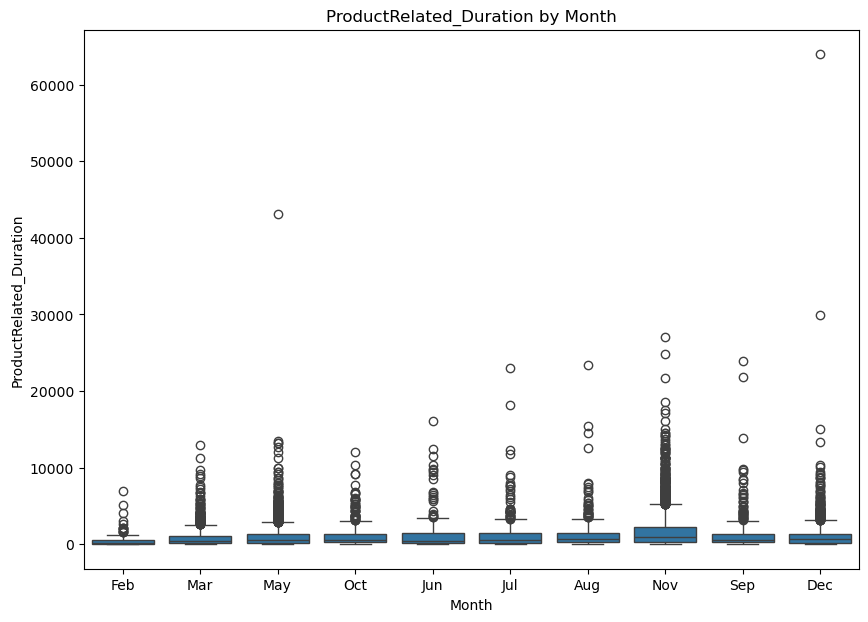

In [130]:
plt.figure(figsize=(10,7))

sns.boxplot(x='Month',
            y='ProductRelated_Duration',
            data=df)

plt.title('ProductRelated_Duration by Month')
plt.xlabel('Month')
plt.ylabel('ProductRelated_Duration')

plt.show()

#### <span style="color:blue">Insight:</span>
November showed the highest average ProductRelated_Duration, reflecting stronger customer engagement during the holiday shopping season.

####  <span style="color:green">Recommendation:</span>
Increase product promotions and marketing efforts during high-engagement months like November to maximize customer activity and revenue.


## <b><u>KEY FINDING SUMMARY<b><u>

- **Only 15.63% of visitors actually buy.**
Out of 12,205 cleaned sessions, only 1,908 resulted in a purchase. 84.37% of visitors browse and leave without buying.

- **Buyers spend 73% more time on product pages.**
Non-buyers averaged 1,083 seconds on product pages. Buyers averaged 1,876 seconds. The more time a user spends on products, the more likely they are to purchase.

- **November is the best month (25.49%), February is the worst (1.66%).**
That is a 15x difference. The business is heavily dependent on a short Nov–Oct festive window. Feb, Mar, Jun are very weak months.

- **New visitors convert at 24.9% vs returning visitors at only 14.1%.**
Returning visitors make up 85.5% of all traffic but convert far less. New visitors convert nearly 2x better despite being only 13.9% of traffic — a clear re-engagement gap.

- **Buyers have 4.5x lower bounce rates than non-buyers.**
Non-buyers: 0.023 avg bounce rate. Buyers: 0.005. Traffic Types 15, 17, 18, and 12 have the highest bounce rates and literally 0% conversion — pure wasted traffic.

- **PageValues of buyers are 13.6x higher than non-buyers.**
Non-buyers averaged PageValue of 2.0. Buyers averaged 27.26. This is the single biggest gap between buyers and non-buyers in the entire dataset — high PageValue pages are where purchases happen.


# <b><u>PREPROCESSING<b><u>

### <b><u>Outlier Detection<b><u>
Outliers are data points that lie significantly far from the majority of observations in a dataset.

In [89]:
df[num_columns].describe( percentiles=[.1,.2,.25,.5,.75, .9, .95, .96, .97, .98,.99]).T

,count,mean,std,min,10%,20%,25%,50%,75%,90%,95%,96%,97%,98%,99%,max
Administrative,12205.00000,2.33888,3.33044,0.00000,0.00000,0.00000,0.00000,1.00000,4.00000,7.00000,9.00000,10.00000,11.00000,12.00000,14.00000,27.00000
Administrative_Duration,12205.00000,81.64633,177.49185,0.00000,0.00000,0.00000,0.00000,9.00000,94.70000,227.00000,352.20810,399.67000,473.96400,598.34500,838.70489,3398.75000
Informational,12205.00000,0.50873,1.27562,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2.00000,3.00000,3.00000,4.00000,5.00000,6.00000,24.00000
Informational_Duration,12205.00000,34.82545,141.42481,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,73.90000,199.00000,246.75200,314.88000,435.17400,722.37920,2549.37500
ProductRelated,12205.00000,32.04564,44.59365,0.00000,3.00000,6.00000,8.00000,18.00000,38.00000,74.00000,110.00000,122.00000,139.00000,162.00000,221.00000,705.00000
ProductRelated_Duration,12205.00000,1206.98246,1919.60140,0.00000,44.50000,137.00000,193.00000,608.94286,1477.15476,2904.45914,4312.95628,4873.96913,5518.92060,6724.21379,8704.27157,63973.52223
BounceRates,12205.00000,0.02037,0.04526,0.00000,0.00000,0.00000,0.00000,0.00290,0.01667,0.05000,0.14933,0.20000,0.20000,0.20000,0.20000,0.20000
ExitRates,12205.00000,0.04147,0.04616,0.00000,0.00741,0.01196,0.01423,0.02500,0.04853,0.10000,0.17371,0.20000,0.20000,0.20000,0.20000,0.20000
PageValues,12205.00000,5.94957,18.65367,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,19.11414,38.30146,44.73587,53.25215,62.86498,86.10869,361.76374
SpecialDay,12205.00000,0.06194,0.19967,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.20000,0.60000,0.60000,0.80000,0.80000,1.00000,1.00000


### <b><u>Outlier Counts<b><u>

In [90]:
outlier_counts = {}
outlier_cols = ["Administrative",
    "Administrative_Duration",
    "Informational",          
    "Informational_Duration",
    "ProductRelated",       
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"]
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_counts[col] = len(outliers)

# Convert to DataFrame for better view
outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier_Count'])
outlier_df.sort_values(by='Outlier_Count', ascending=False)

,Outlier_Count
PageValues,2730
Informational,2631
Informational_Duration,2405
BounceRates,1428
ExitRates,1325
Administrative_Duration,1149
ProductRelated,1007
ProductRelated_Duration,951
Administrative,404


### <b><u>Visualize Outlier Counts<b><u>

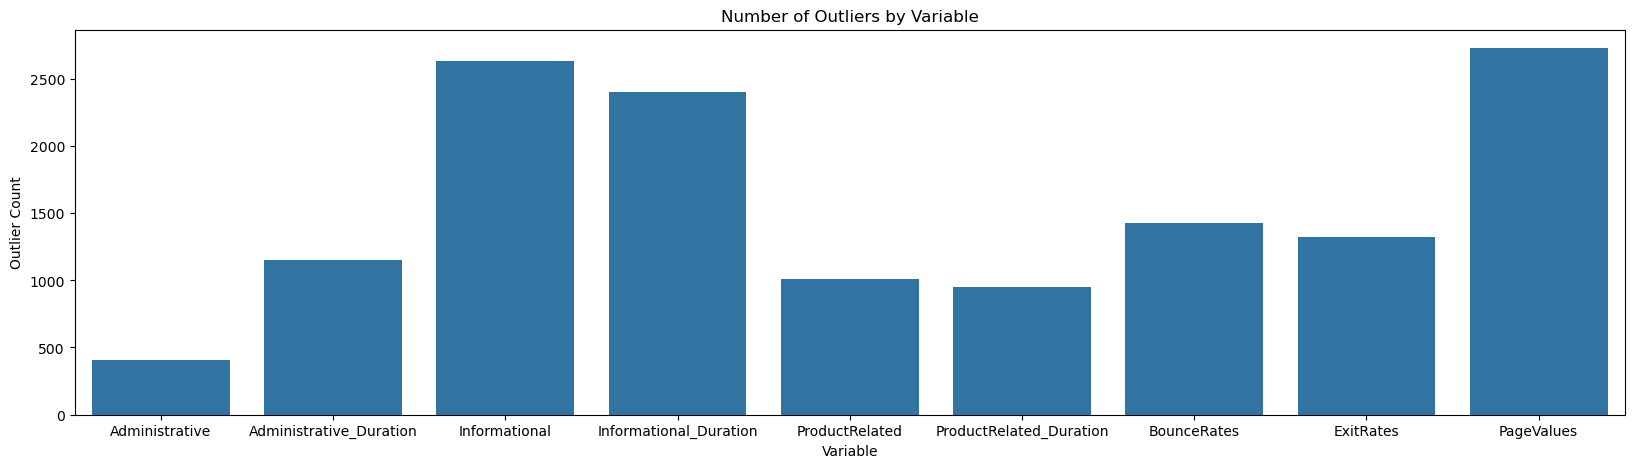

In [91]:
plt.figure(figsize=(20,5))
sns.barplot(x=outlier_df.index, y=outlier_df['Outlier_Count'])
plt.title("Number of Outliers by Variable")
plt.xlabel("Variable")
plt.ylabel("Outlier Count")
plt.show()

### <b><u>Boxplot for Outlier Analysis<b><u>

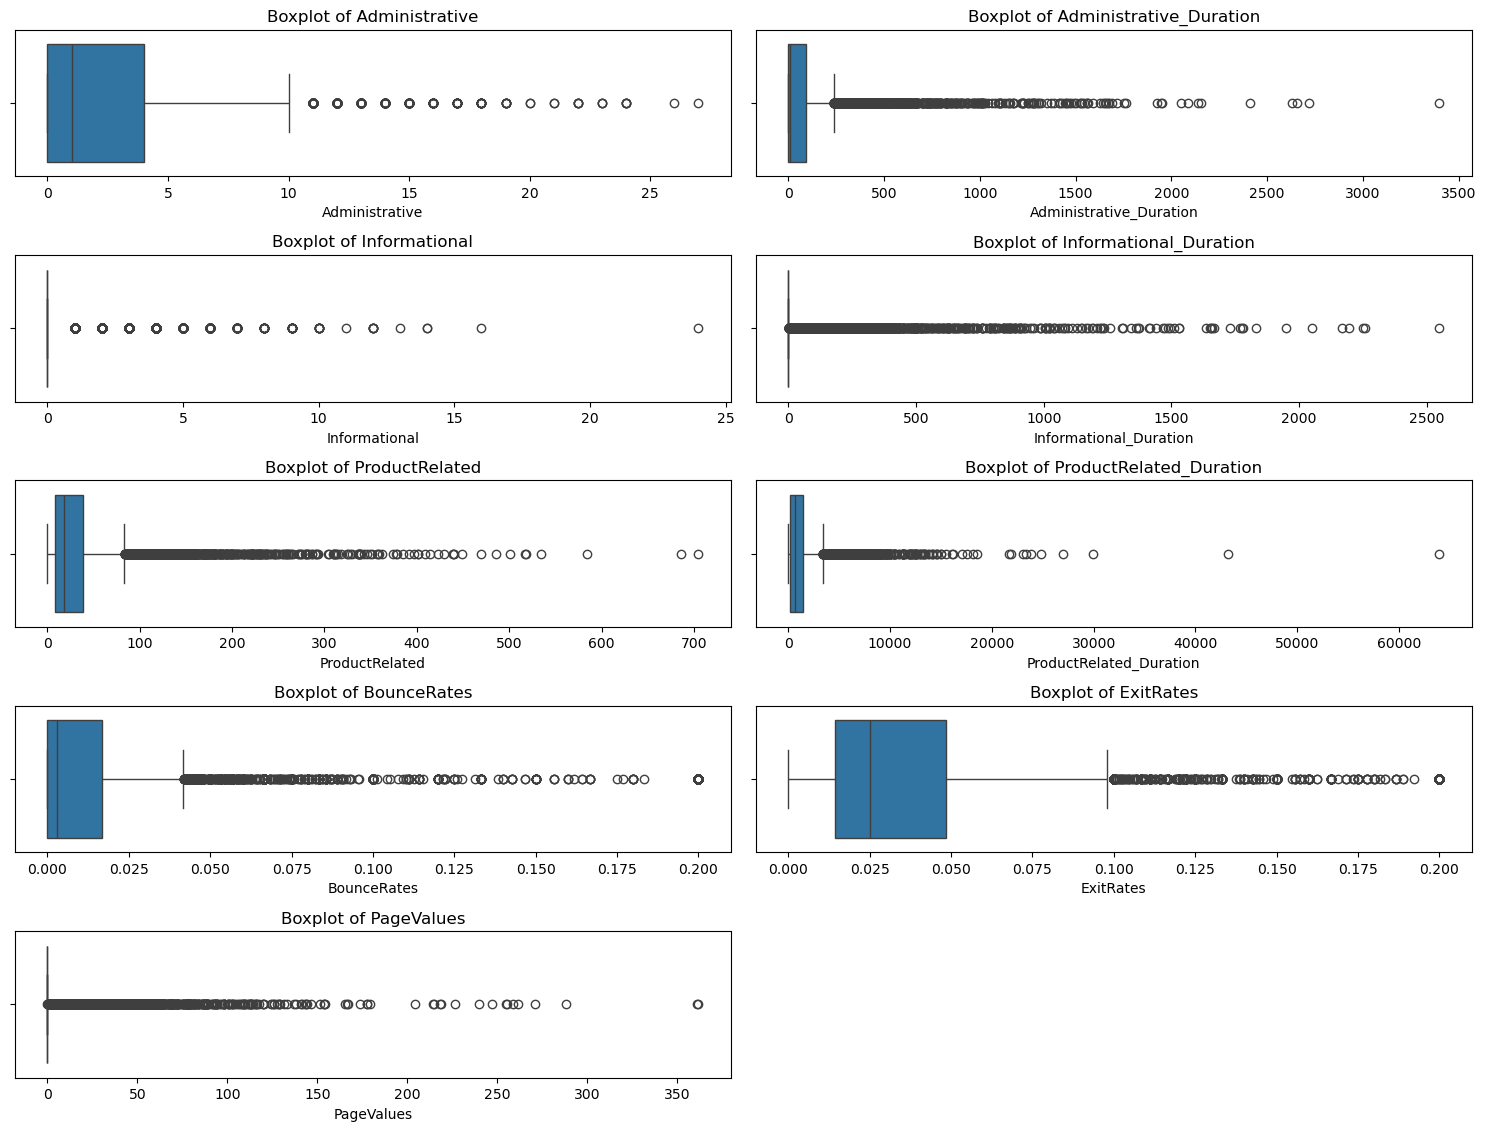

In [92]:
plt.figure(figsize=(15,20))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(len(outlier_cols), 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

## <span style="color:darkblue"> Why Outliers Exist in the Dataset </span>

- <b>Administrative & Administrative_Duration</b> — Some users visited many account or administrative pages repeatedly, such as checking order history, updating account settings, or navigating multiple admin-related pages.

- <b>Informational & Informational_Duration</b> — Most users visited very few informational pages, while a smaller group explored FAQ, policy, and informational sections extensively, creating high variation in the data.

- <b>ProductRelated & ProductRelated_Duration</b> — Certain users browsed a very large number of product pages and spent unusually high time exploring products due to comparison shopping, purchase research, or inactive browser sessions left open.

- <b>BounceRates</b> — High bounce rate outliers occurred because some users left the website immediately after landing on a page, possibly due to irrelevant traffic, accidental clicks, or poor landing page relevance.

- <b>ExitRates</b> — High exit rate outliers indicate sessions where users exited from specific pages, such as checkout abandonment or product comparison behavior before leaving the website.

- <b>PageValues</b> — High PageValue outliers were generated by a smaller group of highly valuable customers who interacted with expensive or high-converting product pages.

# <b><u>Key Business Questions Addressed<b><u>

## 1. Which months generate the highest conversion rates?
Business Need: Identify peak shopping periods to optimize marketing campaigns and inventory planning.

In [93]:
conversion_rate = (
    df.groupby('Month')['Revenue']
      .mean()
      .sort_values(ascending=False) * 100
)

print(conversion_rate)

Month
Nov   25.48625
Oct   20.94718
Sep   19.19643
Aug   17.55196
Jul   15.27778
Dec   12.66120
May   10.96425
Mar   10.32258
Jun   10.17544
Feb    1.65746
Name: Revenue, dtype: float64


#### <span style="color:blue">Insight:</span>
November and October recorded the highest conversion rates, showing strong seasonal purchase intent during festive or sale periods.

####  <span style="color:green">Recommendation:</span>
Increase marketing campaigns and promotional offers during high-conversion months to maximize revenue.

## 2. Which visitor type generates the highest purchase value?

Business Need: Understand whether new or returning visitors contribute more value.

In [94]:
\visitor_value = (
    df.groupby('VisitorType')['PageValues']
      .mean()
      .sort_values(ascending=False)
)

print(visitor_value)

VisitorType
Other               19.09017
New_Visitor         10.77855
Returning_Visitor    5.06377
Name: PageValues, dtype: float64


#### <span style="color:blue">Insight:</span>
New Visitors generated higher PageValues compared to Returning Visitors, indicating stronger purchase value per session.
####  <span style="color:green">Recommendation:</span>
Focus on converting new visitors through personalized onboarding and targeted product recommendations.

## 3. Which traffic sources have the highest conversion rates?

Business Need: Optimize acquisition channels and advertising spend

In [95]:
traffic_conversion = (
    df.groupby('TrafficType')['Revenue']
      .mean().sort_values(ascending=False) * 100
)

print(traffic_conversion)

TrafficType
16   33.33333
7    30.00000
8    27.69679
20   25.90674
2    21.65687
5    21.53846
10   20.00000
11   19.02834
4    15.47842
14   15.38462
6    11.96388
1    10.97152
9     9.75610
3     8.94188
13    5.90659
19    5.88235
12    0.00000
15    0.00000
18    0.00000
17    0.00000
Name: Revenue, dtype: float64


#### <span style="color:blue">Insight:</span>
Traffic Types 16, 7, and 8 generated the strongest conversion performance, while some traffic sources had almost no conversions.
####  <span style="color:green">Recommendation:</span>
Invest more in high-performing traffic channels and optimize or remove low-performing acquisition sources.

## 4. Do users who spend more time on product pages convert more?

Business Need: Measure the relationship between browsing engagement and purchasing behavior.

In [96]:
df.groupby('Revenue')['ProductRelated_Duration'].mean()

Revenue
0   1082.97688
1   1876.20961
Name: ProductRelated_Duration, dtype: float64

#### <span style="color:blue">Insight:</span>
Users who converted spent significantly more time on product pages than non-converting users.
####  <span style="color:green">Recommendation:</span>
Improve product content, images, and recommendations to encourage deeper product exploration.

## 5. How do bounce rates affect conversions?

Business Need: Identify friction points causing users to leave early.

In [97]:
df.groupby('Revenue')['BounceRates'].mean()

Revenue
0   0.02320
1   0.00512
Name: BounceRates, dtype: float64

#### <span style="color:blue">Insight:</span>
Converted users had much lower bounce rates, indicating better engagement and smoother user journeys.
####  <span style="color:green">Recommendation:</span>
Optimize landing pages and ad targeting to reduce bounce behavior.

## 6. Which months show the highest product engagement?

Business Need: Understand seasonal browsing trends.

In [98]:
monthly_engagement = (
    df.groupby('Month')['ProductRelated_Duration']
      .mean().sort_values(ascending=False)
)

print(monthly_engagement)

Month
Nov   1767.83265
Aug   1272.65365
Sep   1253.38815
Jun   1226.15000
Jul   1217.60403
Dec   1125.15237
Oct   1116.97768
May    992.21636
Mar    832.80842
Feb    478.82152
Name: ProductRelated_Duration, dtype: float64


#### <span style="color:blue">Insight:</span>
November showed the highest product engagement, followed by August and September.
####  <span style="color:green">Recommendation:</span>
Launch major product campaigns during high-engagement months to improve conversion opportunities.

## 7. Are returning visitors more engaged than new visitors?

Business Need: Evaluate customer loyalty and retention behavior.

In [99]:
visitor_engagement = (
    df.groupby('VisitorType')['ProductRelated']
      .mean().sort_values(ascending=False)
)

print(visitor_engagement)

VisitorType
Returning_Visitor   34.46237
New_Visitor         18.06497
Other               13.03704
Name: ProductRelated, dtype: float64


#### <span style="color:blue">Insight:</span>
Returning Visitors browsed significantly more product pages than New Visitors, reflecting higher engagement.
####  <span style="color:green">Recommendation:</span>
Use loyalty programs and remarketing campaigns to retain engaged returning customers.

## 8. Which traffic types generate high bounce rates?

Business Need: Detect low-quality traffic sources.

In [100]:
traffic_bounce = (
    df.groupby('TrafficType')['BounceRates']
      .mean()
      .sort_values(ascending=False)
)

print(traffic_bounce)

TrafficType
15   0.06641
17   0.05000
13   0.04663
18   0.03313
3    0.03008
1    0.02792
19   0.02575
20   0.02307
11   0.02221
9    0.02211
6    0.02170
10   0.01663
4    0.01574
8    0.01150
5    0.00945
2    0.00836
7    0.00782
14   0.00243
12   0.00000
16   0.00000
Name: BounceRates, dtype: float64


#### <span style="color:blue">Insight:</span>
Traffic Types 15, 17, and 13 had the highest bounce rates, indicating poor-quality traffic.
####  <span style="color:green">Recommendation:</span>
Review traffic acquisition strategies and improve landing page relevance for these traffic sources.

## 9. How does Page Value relate to conversions?

Business Need: Understand whether higher-value pages increase purchase success.

In [101]:
df.groupby('Revenue')['PageValues'].mean()

Revenue
0    1.99999
1   27.26452
Name: PageValues, dtype: float64

#### <span style="color:blue">Insight:</span>
Converted users had dramatically higher PageValues, showing strong correlation between PageValue and purchase success.
####  <span style="color:green">Recommendation:</span>
Focus on optimizing high-value product pages and recommendation systems.

## 10. Do weekend visitors convert better?

Business Need: Measure weekend shopping behavior.

In [102]:
weekend_conversion = (
    df.groupby('Weekend')['Revenue']
      .mean() * 100
)

print(weekend_conversion)

Weekend
0   15.07597
1   17.45366
Name: Revenue, dtype: float64


#### <span style="color:blue">Insight:</span>
Weekend visitors showed slightly higher conversion rates compared to weekday visitors.
####  <span style="color:green">Recommendation:</span>
Increase weekend promotions and targeted campaigns to capture higher purchase intent.

## 11. Does SpecialDay proximity influence purchases?

Business Need: Measure the effect of holidays and events on revenue.

In [103]:
specialday_conversion = (
    df.groupby('SpecialDay')['Revenue']
      .mean() * 100
)

print(specialday_conversion)

SpecialDay
0.00000   16.71230
0.20000    7.86517
0.40000    5.34979
0.60000    8.28571
0.80000    3.39506
1.00000    6.49351
Name: Revenue, dtype: float64


#### <span style="color:blue">Insight:</span>
Conversion rates were highest when SpecialDay was 0, suggesting regular shopping periods outperformed holiday proximity periods.
####  <span style="color:green">Recommendation:</span>
Do not rely only on holiday-based promotions; maintain strong year-round engagement strategies.

## 12. Which browser groups generate better conversions?

Business Need: Optimize website compatibility and user experience.

In [104]:
browser_conversion = (
    df.groupby('Browser')['Revenue']
      .mean().sort_values(ascending=False) * 100
)

print(browser_conversion)

Browser
12   30.00000
13   28.57143
10   19.63190
5    18.49462
4    17.78386
11   16.66667
8    15.55556
2    15.51440
1    15.03914
7    12.24490
6    11.49425
3     4.76190
9     0.00000
Name: Revenue, dtype: float64


#### <span style="color:blue">Insight:</span>
Certain browser groups showed significantly higher conversion rates, while Browser 3 and 9 underperformed.
####  <span style="color:green">Recommendation:</span>
Optimize website compatibility and user experience for lower-performing browsers.

## 13. Which regions contribute the highest revenue?

Business Need: Understand regional customer behavior.

In [105]:
region_conversion = (
    df.groupby('Region')['Revenue']
      .mean().sort_values(ascending=False)* 100
)

print(region_conversion)

Region
9   17.02970
2   16.66667
1   16.35554
5   16.35220
7   15.69921
4   14.94449
3   14.67003
6   13.98252
8   12.99304
Name: Revenue, dtype: float64


#### <span style="color:blue">Insight:</span>
Regions 9, 2, 1 and 5 showed the highest conversion rates, while Region 8 had the lowest.
####  <span style="color:green">Recommendation:</span>
Focus regional marketing efforts on high-performing regions while improving engagement in weaker markets.

## 14. Do users with lower exit rates convert more?

Business Need: Identify website abandonment patterns.

In [106]:
df.groupby('Revenue')['ExitRates'].mean()

Revenue
0   0.04553
1   0.01956
Name: ExitRates, dtype: float64

#### <span style="color:blue">Insight:</span>
Converted users had much lower exit rates, indicating smoother navigation and better purchase flow.
####  <span style="color:green">Recommendation:</span>
Improve high-exit pages and simplify the customer journey to reduce abandonment.

## 15. Which month-visitor type combination produces the highest conversions?
Business Need: To determine the best-performing customer segments during specific months so the business can optimize seasonal marketing campaigns and promotional activities.

In [107]:
pivot = df.groupby(['Month','VisitorType']).agg(
      Sessions    = ('Revenue','count'),
      Conversions = ('Revenue','sum')
      ).reset_index()
pivot['Conv_Rate_%'] = (pivot['Conversions'] / pivot['Sessions'] * 100).round(2)
pivot = pivot.sort_values('Conv_Rate_%', ascending=False)
print(pivot.head(10))

   Month        VisitorType  Sessions  Conversions  Conv_Rate_%
16   Nov        New_Visitor       419          128     30.55000
0    Aug        New_Visitor        72           21     29.17000
14   May        New_Visitor       319           88     27.59000
21   Sep        New_Visitor       108           28     25.93000
18   Nov  Returning_Visitor      2541          629     24.75000
9    Jun        New_Visitor        30            7     23.33000
19   Oct        New_Visitor       124           28     22.58000
2    Dec        New_Visitor       334           75     22.46000
3    Dec              Other        58           13     22.41000
20   Oct  Returning_Visitor       425           87     20.47000


#### <span style="color:blue">Insight:</span>
New Visitors in November showed the highest conversion rate, followed by New Visitors in August and May.
####  <span style="color:green">Recommendation:</span>
Target new visitors aggressively during peak months with personalized campaigns and seasonal offers.

## 16. Which visitor type converts the best — New or Returning?
Business need: To identify which customer segment has higher purchase intent and better conversion performance, helping the business improve customer targeting and retention strategies.

In [108]:
conversion_rate = (
    df.groupby('VisitorType')['Revenue']
      .mean() * 100
)

print(conversion_rate)

VisitorType
New_Visitor         24.92617
Other               19.75309
Returning_Visitor   14.09261
Name: Revenue, dtype: float64


#### <span style="color:blue">Insight:</span>
New Visitors had the highest conversion rate, outperforming Returning Visitors.
####  <span style="color:green">Recommendation:</span>
Improve first-time visitor experience and strengthen acquisition strategies to maximize new customer conversions.

## 17.Do users who browse more pages convert better?
Business Need: To understand whether deeper website exploration increases purchase probability.

In [109]:
df.groupby('Revenue')['TotalPages'].mean()

Revenue
0   31.65116
1   52.38994
Name: TotalPages, dtype: float64

#### <span style="color:blue">Insight:</span>
Users who converted visited significantly more pages on average compared to non-converting users, indicating stronger engagement and higher purchase intent.
####  <span style="color:green">Recommendation:</span>
Improve internal navigation, product recommendations, and related product sections to encourage deeper website exploration.

## 18. Do longer sessions lead to higher purchase intent?
Business Need: To measure whether users spending more total time on the website are more likely to complete a purchase.

In [110]:
df.groupby('Revenue')['TotalDuration'].mean()

Revenue
0   1188.21545
1   2053.30429
Name: TotalDuration, dtype: float64

#### <span style="color:blue">Insight:</span>
Converted users spent substantially more time on the website, showing that longer browsing sessions are strongly associated with purchase behavior.
####  <span style="color:green">Recommendation:</span>
Enhance user engagement through interactive content, personalized recommendations, and optimized product pages to increase session duration and conversions.

# <b><u>Overall Insights<b><u>

- **User Engagement Drives Conversions**

    Users with higher session duration, more page visits, and deeper product browsing were more likely to make purchases.

- **Seasonal Months Perform**

    November, October, and September recorded the highest conversion rates and customer engagement.

- **Bounce Rate & Exit Rates Impacts Revenue**

    Sessions with lower Bounce Rates and Exit Rates generated significantly higher conversions.

- **New Visitors Show Strong Purchase Intent**

    New visitors achieved higher conversion rates and Page Values compared to returning visitors.

- **Returning visitors browse but don't buy**

    They dominate 85.5% of traffic but convert at just 14.1% with low PageValues (5.06). They are engaged but not purchasing.
 
- **Traffic Source Quality Matters**

   Some Traffic Types generated high conversions with low bounce rates, while others showed poor engagement.

- **Product Interaction Influences Purchases**

    Higher ProductRelated pages and ProductRelated_Duration strongly indicated stronger buying intent.

- **Website Experience Affects Conversions**

    High exit and bounce behavior suggest potential friction points in navigation, landing pages, or checkout flow.

- **Special day promotions are not working**
    
    When SpecialDay = 0 (no holiday), conversion is 16.71%. As the special day gets closer (SpecialDay = 1.0), conversion drops to      6.49%. Holiday urgency is backfiring.

- **Region 9, 2, and 1 are top converting regions**

    Region 8 is the weakest at 12.99%. Regional behavior differences exist and can be targeted.

# <b><u>Business Recommendations<b><u>

- **Build a proper seasonal calendar**

    Plan your biggest campaigns, stock, and offers from September onwards. Don't wait for November. Use February and March for          brand awareness, email list building, or new visitor acquisition to reduce revenue dependency on 2 months.
  
- **Cut bad traffic sources immediately**

    Traffic Types 12, 15, 17, and 18 have 0% conversion with high bounce rates. These are wasting your acquisition budget. Shift        that spend toward Types 16, 7, and 8 which convert at 27–33% with low bounce rates 

- **Re-engage returning visitors urgently**

    They are 85.5% of your traffic but convert at only 14.1%. Use personalized recommendations, retargeting campaigns, and loyalty      programs to convert highly engaged returning visitors into paying customers.
  
- **Invest in product page experience** 

    This is where the purchase decision is made. Add detailed descriptions, customer reviews, comparison features, and smart            "related products" sections to keep users exploring longer.

- **Reduce Bounce Rate Through Better Landing Page Experience**

    Optimize landing pages and website navigation to reduce bounce rates and improve session engagement, especially for returning       visitors

- **Fix High-Exit Pages**  

    Analyze high-exit pages and optimize checkout processes to reduce cart abandonment and improve overall conversion efficiency.

- **Target new visitors aggressively through top channels** 

    New visitors convert at 24.9% — nearly 2x better. Acquiring more new visitors via high-performing traffic sources (Types 16, 7,     8) is the highest ROI action available.

- **Run region-specific campaigns** 

    Regions 9, 2, and 1 convert best. Focus promotional spend there. For Region 8 (lowest at 12.99%), test different messaging or       offers to understand and fix the drop-off.

# <b><u>Conclusion<b><u>

- The cleaned dataset of 12,205 sessions shows a conversion rate of 15.63% — meaning 84.37% of visitors leave without buying.
  
- The data tells a very clear story: engaged users buy, disengaged users don't. Buyers spend 73% more time on product pages, visit 65% more pages, have 4.5x lower bounce rates, and generate 13.6x higher PageValues than non-buyers.

  
- The biggest fixable problem is returning visitors — they dominate traffic but underconvert. Even a 3–4% improvement in their conversion rate would add hundreds of additional purchases.

  
- The business is dangerously seasonal — November–October drives the majority of conversions while February sits at just 1.66%. A structured off-peak engagement strategy is needed to stabilize revenue year-round.

  
- Special day promotions are counterproductive based on the data. Regular non-holiday periods convert at 16.71% vs just 6.49% on special days. This strategy needs to be reviewed.

  
- Fixing traffic quality, improving product page experience, and re-converting returning visitors are the three highest-impact actions this business can take — without needing to increase overall traffic volume.

In [111]:
df.to_csv("cleaned_shoppers.csv", index=False)
print("File saved successfully")

File saved successfully
